In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
import os
import glob
import json
import pickle
from io import BytesIO
from pathlib import Path
from abc import ABC, abstractmethod
import tempfile 
import struct

import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance, ImageFilter

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

from IPython.display import display, Markdown

import joblib
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as ort
from ultralytics import YOLO
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="ultralytics")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.linear_model._base")
warnings.filterwarnings("ignore", category=UserWarning, module="ultralytics")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.metrics")

TEMP_DIR_ON_D = "D:/temp_for_ml"
os.makedirs(TEMP_DIR_ON_D, exist_ok=True)
tempfile.tempdir = TEMP_DIR_ON_D

os.environ['TORCH_HOME'] = 'D:/temp_for_ml/torch_cache'
os.environ['ULTRALYTICS_HOME'] = 'D:/temp_for_ml/ultralytics_cache'

ORL_PATH = r"orl_faces"
FRUITS_PATH = r"fruits-360_100x100/fruits-360/Training"
RTSD_PATH = r"gtrsd/Train"
MATH_SYMBOLS_PATH = r"handwritten_math_symbols/extracted_images"
DIGITS_PATH = r"handwritten_digits/img"
RUSSIAN_LETTERS_PATH = r"russian_letters/all_letters_image/all_letters_image"
RUSSIAN_LETTERS_CSV = r"russian_letters/all_letters_info.csv"
TARGET_SIZE = (100, 100)
GRAY = True

TEST_SIZE = 0.2
RANDOM_STATE = 42
TRAIN_SIZE_FRACS = [0.1, 0.25, 0.5, 0.75, 1.0]

PCA_N_COMPONENTS_DEFAULT = 100
KNN_NEIGHBORS_DEFAULT = 3

MAX_PER_CLASS_FRUITS = 30
MAX_PER_CLASS_ORL = None
MAX_PER_CLASS_RTSD = 40

BLUR_THRESHOLD = 100.0
LOW_CONTRAST_STD = 10.0
VERY_BRIGHT = 245
VERY_DARK = 10

DEFAULT_THRESHOLD = 0.85
EXAMPLE_ROOT = Path("experiment_examples")
MODEL_ROOT = Path("saved_models")

HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (7, 7)
HOG_CELLS_PER_BLOCK = (2, 2)

def _get_pil_resample():
    try:
        return Image.Resampling.LANCZOS
    except AttributeError:
        return Image.LANCZOS if hasattr(Image, "LANCZOS") else Image.BICUBIC

_RESAMPLE = _get_pil_resample()

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)
    return Path(path)

def variance_of_laplacian(grayscale_arr):
    try:
        import cv2
        lap = cv2.Laplacian(grayscale_arr, cv2.CV_64F)
        return float(lap.var())
    except Exception:
        a = np.pad(grayscale_arr.astype(np.float32), ((1, 1), (1, 1)), mode="reflect")
        lap = (
            a[:-2, 1:-1]
            + a[2:, 1:-1]
            + a[1:-1, :-2]
            + a[1:-1, 2:]
            - 4 * a[1:-1, 1:-1]
        )
        return float(np.var(lap))

class Preprocessor(ABC):
    @abstractmethod
    def process(self, img: Image.Image) -> Image.Image:
        raise NotImplementedError

class NoOpPreprocessor(Preprocessor):
    def process(self, img): return img

class ContrastAdjust(Preprocessor):
    def __init__(self, factor=1.2): self.factor = factor
    def process(self, img): return ImageEnhance.Contrast(img).enhance(self.factor)

class AddGaussianNoise(Preprocessor):
    def __init__(self, sigma=5.0): self.sigma = sigma
    def process(self, img):
        arr = np.array(img).astype(np.float32)
        noise = np.random.normal(0.0, self.sigma, arr.shape)
        res = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(res)

class GaussianBlurPreprocessor(Preprocessor):
    def __init__(self, radius=1.5): self.radius = radius
    def process(self, img): return img.filter(ImageFilter.GaussianBlur(self.radius))

class JpegCompressionPreprocessor(Preprocessor):
    def __init__(self, quality=60): self.quality = int(quality)
    def process(self, img):
        bio = BytesIO()
        img.save(bio, format="JPEG", quality=self.quality)
        bio.seek(0)
        return Image.open(bio).convert(img.mode)

class BinarizeOtsu(Preprocessor):
    def process(self, img):
        try:
            if img.mode != 'L':
                img = img.convert('L')
            arr = np.array(img)
            from skimage.filters import threshold_otsu
            thresh = threshold_otsu(arr)
            binary = (arr > thresh).astype(np.uint8) * 255
            return Image.fromarray(binary)
        except Exception:
            return img

class CropToContent(Preprocessor):
    def __init__(self, target_size=(100,100), padding=2):
        self.target_size = target_size
        self.padding = padding

    def process(self, img):
        try:
            arr = np.array(img)
            if arr.ndim == 3:
                arr_gray = arr.mean(axis=2)
            else:
                arr_gray = arr
            coords = np.argwhere(arr_gray < 250)
            if len(coords) == 0:
                img_copy = img.copy()
                img_copy.thumbnail(self.target_size, resample=_RESAMPLE)
                new_img = Image.new('L' if img.mode=='L' else 'RGB', self.target_size, color=255)
                offset = ((self.target_size[0] - img_copy.size[0]) // 2,
                          (self.target_size[1] - img_copy.size[1]) // 2)
                new_img.paste(img_copy, offset)
                return new_img
            y_min, x_min = coords.min(axis=0)
            y_max, x_max = coords.max(axis=0)
            h, w = arr_gray.shape
            y_min = max(0, y_min - self.padding)
            y_max = min(h, y_max + self.padding)
            x_min = max(0, x_min - self.padding)
            x_max = min(w, x_max + self.padding)
            cropped = img.crop((x_min, y_min, x_max, y_max))
            cropped.thumbnail(self.target_size, resample=_RESAMPLE)
            new_img = Image.new('L' if img.mode=='L' else 'RGB', self.target_size, color=255)
            offset = ((self.target_size[0] - cropped.size[0]) // 2,
                      (self.target_size[1] - cropped.size[1]) // 2)
            new_img.paste(cropped, offset)
            return new_img
        except Exception:
            img_copy = img.copy()
            img_copy.thumbnail(self.target_size, resample=_RESAMPLE)
            new_img = Image.new('L' if img.mode=='L' else 'RGB', self.target_size, color=255)
            offset = ((self.target_size[0] - img_copy.size[0]) // 2,
                      (self.target_size[1] - img_copy.size[1]) // 2)
            new_img.paste(img_copy, offset)
            return new_img

class Deskew(Preprocessor):
    def __init__(self, max_angle=30): self.max_angle = max_angle
    def process(self, img):
        try:
            import cv2
            gray = np.array(img.convert('L'))
            _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            coords = np.column_stack(np.where(binary > 0))
            if len(coords) < 5: return img
            mean = np.mean(coords, axis=0)
            cov = np.cov(coords.T)
            eigvals, eigvecs = np.linalg.eig(cov)
            idx = np.argmax(eigvals)
            vec = eigvecs[:, idx]
            angle = np.arctan2(vec[1], vec[0]) * 180 / np.pi
            (h, w) = gray.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            rotated = cv2.warpAffine(gray, M, (w, h),
                                     flags=cv2.INTER_CUBIC,
                                     borderMode=cv2.BORDER_CONSTANT,
                                     borderValue=255)
            return Image.fromarray(rotated)
        except Exception:
            return img

def load_images_from_csv(
    csv_path, images_root, target_size=(100,100), gray=True,
    max_per_class=None, preprocessors=None, blur_thr=BLUR_THRESHOLD,
    low_contrast_thr=LOW_CONTRAST_STD, save_removed_csv=None,
    file_col='file', label_col='label',
):
    df = pd.read_csv(csv_path)
    if file_col not in df.columns or label_col not in df.columns:
        raise ValueError(f"CSV must contain '{file_col}' and '{label_col}' columns")
    if max_per_class is not None:
        class_counts = df[label_col].value_counts().to_dict()
        keep_indices = []
        rng = np.random.RandomState(RANDOM_STATE)
        for cls, count in class_counts.items():
            cls_df = df[df[label_col] == cls]
            if len(cls_df) > max_per_class:
                cls_df = cls_df.sample(n=max_per_class, random_state=rng)
            keep_indices.extend(cls_df.index.tolist())
        df = df.loc[keep_indices]

    X, y, files, removed = [], [], [], []
    preprocessors = preprocessors or []
    for _, row in df.iterrows():
        rel_path = row[file_col]
        label = row[label_col]
        img_path = os.path.join(images_root, rel_path)
        try:
            img = Image.open(img_path)
            img.load()
        except Exception as e:
            removed.append({"file": img_path, "class": label, "reason": f"corrupted:{e}"})
            continue
        try:
            for p in preprocessors:
                img = p.process(img)
        except Exception as e:
            removed.append({"file": img_path, "class": label, "reason": f"preproc_failed:{e}"})
            continue
        if gray:
            img = img.convert("L")
        else:
            img = img.convert("RGB")
        img = img.resize(target_size, resample=_RESAMPLE)
        arr = np.asarray(img, dtype=np.uint8)

        try:
            lap_var = variance_of_laplacian(arr if arr.ndim == 2 else arr.mean(axis=2))
            if blur_thr != -1 and lap_var < blur_thr:
                removed.append({"file": img_path, "class": label, "reason": f"blur({lap_var:.1f})"})
                continue
        except Exception:
            pass
        stdv = float(arr.std())
        if low_contrast_thr != -1 and stdv < low_contrast_thr:
            removed.append({"file": img_path, "class": label, "reason": f"low_contrast({stdv:.2f})"})
            continue
        meanv = float(arr.mean())
        if (VERY_BRIGHT is not None and meanv > VERY_BRIGHT) or (VERY_DARK is not None and meanv < VERY_DARK):
            removed.append({"file": img_path, "class": label, "reason": f"too_extreme({meanv:.1f})"})
            continue

        X.append(arr.flatten())
        y.append(label)
        files.append(img_path)

    X_arr = np.vstack(X).astype(np.float32) if X else np.empty((0,))
    y_arr = np.array(y)
    if save_removed_csv and removed:
        pd.DataFrame(removed).to_csv(save_removed_csv, index=False)
    return X_arr, y_arr, files, removed

def load_images_flexible_with_clean(
    root_folder, target_size=(100,100), gray=True, max_per_class=None,
    preprocessors=None, blur_thr=BLUR_THRESHOLD, low_contrast_thr=LOW_CONTRAST_STD,
    save_removed_csv=None, csv_file=None, csv_file_col='file', csv_label_col='label',
    filename_parser=None,
):
    if csv_file is not None:
        return load_images_from_csv(
            csv_path=csv_file, images_root=root_folder, target_size=target_size,
            gray=gray, max_per_class=max_per_class, preprocessors=preprocessors,
            blur_thr=blur_thr, low_contrast_thr=low_contrast_thr,
            save_removed_csv=save_removed_csv, file_col=csv_file_col, label_col=csv_label_col,
        )
    if filename_parser is not None:
        X, y, files, removed = [], [], [], []
        preprocessors = preprocessors or []
        patterns = ["*.jpg","*.JPG","*.jpeg","*.JPEG","*.png","*.PNG","*.pgm","*.PGM","*.bmp","*.BMP","*.gif","*.GIF","*.cmx","*.CMX"]
        all_img_paths = []
        for p in patterns:
            all_img_paths.extend(glob.glob(os.path.join(root_folder, "**", p), recursive=True))
        all_img_paths = sorted(all_img_paths)
        class_to_paths = {}
        for path in all_img_paths:
            try:
                cls = filename_parser(path)
                if cls is None: continue
                class_to_paths.setdefault(cls, []).append(path)
            except Exception:
                continue
        for cls, paths in class_to_paths.items():
            if max_per_class is not None and len(paths) > max_per_class:
                rng = np.random.RandomState(RANDOM_STATE)
                paths = list(rng.choice(paths, size=max_per_class, replace=False))
            for img_path in paths:
                try:
                    img = Image.open(img_path)
                    img.load()
                except Exception as e:
                    removed.append({"file": img_path, "class": cls, "reason": f"corrupted:{e}"})
                    continue
                try:
                    for p in preprocessors:
                        img = p.process(img)
                except Exception as e:
                    removed.append({"file": img_path, "class": cls, "reason": f"preproc_failed:{e}"})
                    continue
                if gray:
                    img = img.convert("L")
                else:
                    img = img.convert("RGB")
                img = img.resize(target_size, resample=_RESAMPLE)
                arr = np.asarray(img, dtype=np.uint8)
                X.append(arr.flatten())
                y.append(cls)
                files.append(img_path)
        X_arr = np.vstack(X).astype(np.float32) if X else np.empty((0,))
        y_arr = np.array(y)
        if save_removed_csv and removed:
            pd.DataFrame(removed).to_csv(save_removed_csv, index=False)
        return X_arr, y_arr, files, removed

    if not os.path.exists(root_folder):
        raise FileNotFoundError(f"Path '{root_folder}' does not exist.")
    subdirs = sorted([d for d in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, d))])
    X, y, files, removed = [], [], [], []
    preprocessors = preprocessors or []
    patterns = ["*.jpg", "*.png", "*.jpeg", "*.pgm", "*.bmp"]
    for cls in subdirs:
        cls_folder = os.path.join(root_folder, cls)
        imgs = []
        for p in patterns:
            imgs += glob.glob(os.path.join(cls_folder, p))
        imgs = sorted(imgs)
        if not imgs: continue
        if max_per_class is not None:
            imgs = imgs[:max_per_class]
        for img_path in imgs:
            try:
                img = Image.open(img_path)
                img.load()
            except Exception as e:
                removed.append({"file": img_path, "class": cls, "reason": f"corrupted:{e}"})
                continue
            try:
                for p in preprocessors:
                    img = p.process(img)
            except Exception as e:
                removed.append({"file": img_path, "class": cls, "reason": f"preproc_failed:{e}"})
                continue
            if gray:
                img = img.convert("L")
            else:
                img = img.convert("RGB")
            img = img.resize(target_size, resample=_RESAMPLE)
            arr = np.asarray(img, dtype=np.uint8)

            try:
                lap_var = variance_of_laplacian(arr if arr.ndim == 2 else arr.mean(axis=2))
                if blur_thr != -1 and lap_var < blur_thr:
                    removed.append({"file": img_path, "class": cls, "reason": f"blur({lap_var:.1f})"})
                    continue
            except Exception:
                lap_var = None

            stdv = float(arr.std())
            if low_contrast_thr != -1 and stdv < low_contrast_thr:
                removed.append({"file": img_path, "class": cls, "reason": f"low_contrast({stdv:.2f})"})
                continue

            meanv = float(arr.mean())
            if (VERY_BRIGHT is not None and meanv > VERY_BRIGHT) or (VERY_DARK is not None and meanv < VERY_DARK):
                removed.append({"file": img_path, "class": cls, "reason": f"too_extreme({meanv:.1f})"})
                continue

            X.append(arr.flatten())
            y.append(cls)
            files.append(img_path)

    X_arr = np.vstack(X).astype(np.float32) if X else np.empty((0,))
    y_arr = np.array(y)
    if save_removed_csv and removed:
        pd.DataFrame(removed).to_csv(save_removed_csv, index=False)
    return X_arr, y_arr, files, removed

def _load_example_images(root_folder, max_classes=3, images_per_class=1, max_per_class=None, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    subdirs = sorted([d for d in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, d))])
    if max_classes is not None:
        if len(subdirs) > max_classes:
            subdirs = list(rng.choice(subdirs, size=max_classes, replace=False))
            subdirs.sort()
    patterns = ["*.jpg", "*.png", "*.jpeg", "*.pgm", "*.bmp"]
    selected = []
    for cls in subdirs:
        cls_folder = os.path.join(root_folder, cls)
        imgs = []
        for p in patterns:
            imgs += glob.glob(os.path.join(cls_folder, p))
        imgs = sorted(imgs)
        if not imgs: continue
        if max_per_class is not None:
            imgs = imgs[:max_per_class]
        if images_per_class is not None and len(imgs) > images_per_class:
            imgs = list(rng.choice(imgs, size=images_per_class, replace=False))
        for img_path in imgs:
            selected.append((img_path, cls))
    return selected

def _open_image_safe(path):
    img = Image.open(path)
    img.load()
    return img

def save_transform_example(input_path, preprocessor, output_dir, tag, target_size=(100,100), gray=True):
    output_dir = ensure_dir(output_dir)
    base = _open_image_safe(input_path)
    if gray:
        base_vis = base.convert("L")
    else:
        base_vis = base.convert("RGB")
    base_vis = base_vis.resize(target_size, resample=_RESAMPLE)
    try:
        transformed = preprocessor.process(base)
        if gray:
            transformed = transformed.convert("L")
        else:
            transformed = transformed.convert("RGB")
        transformed = transformed.resize(target_size, resample=_RESAMPLE)
    except Exception as e:
        print(f"[example save] failed for {tag}: {e}")
        return None
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(base_vis, cmap="gray" if gray else None)
    axes[0].set_title("original")
    axes[0].axis("off")
    axes[1].imshow(transformed, cmap="gray" if gray else None)
    axes[1].set_title(tag)
    axes[1].axis("off")
    plt.tight_layout()
    out_path = output_dir / f"{tag}.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return out_path

def save_noise_examples(dataset_name, dataset_path, sigmas=(0.0,4.0,8.0), target_size=(100,100), gray=True, max_per_class=None, base_output_dir=EXAMPLE_ROOT, max_classes=3, images_per_class=1):
    output_dir = base_output_dir / dataset_name / "noise"
    examples = _load_example_images(dataset_path, max_classes=max_classes, images_per_class=images_per_class, max_per_class=max_per_class)
    if not examples: return []
    paths = []
    for img_path, cls in examples:
        for sigma in sigmas:
            prep = NoOpPreprocessor() if sigma==0.0 else AddGaussianNoise(sigma)
            tag = f"{cls}_noise_sigma_{sigma:g}_{Path(img_path).stem}"
            paths.append(save_transform_example(img_path, prep, output_dir/cls, tag, target_size=target_size, gray=gray))
    return paths

def save_blur_examples(dataset_name, dataset_path, radii=(0.0,1.5,3.0), target_size=(100,100), gray=True, max_per_class=None, base_output_dir=EXAMPLE_ROOT, max_classes=3, images_per_class=1):
    output_dir = base_output_dir / dataset_name / "blur"
    examples = _load_example_images(dataset_path, max_classes=max_classes, images_per_class=images_per_class, max_per_class=max_per_class)
    if not examples: return []
    paths = []
    for img_path, cls in examples:
        for r in radii:
            prep = NoOpPreprocessor() if r==0.0 else GaussianBlurPreprocessor(r)
            tag = f"{cls}_blur_radius_{r:g}_{Path(img_path).stem}"
            paths.append(save_transform_example(img_path, prep, output_dir/cls, tag, target_size=target_size, gray=gray))
    return paths

def save_jpeg_examples(dataset_name, dataset_path, qualities=(30,60,95), target_size=(100,100), gray=True, max_per_class=None, base_output_dir=EXAMPLE_ROOT, max_classes=3, images_per_class=1):
    output_dir = base_output_dir / dataset_name / "jpeg"
    examples = _load_example_images(dataset_path, max_classes=max_classes, images_per_class=images_per_class, max_per_class=max_per_class)
    if not examples: return []
    paths = []
    for img_path, cls in examples:
        for q in qualities:
            tag = f"{cls}_jpeg_quality_{q}_{Path(img_path).stem}"
            paths.append(save_transform_example(img_path, JpegCompressionPreprocessor(q), output_dir/cls, tag, target_size=target_size, gray=gray))
    return paths

def save_contrast_examples(dataset_name, dataset_path, factors=(0.8,1.4), target_size=(100,100), gray=True, max_per_class=None, base_output_dir=EXAMPLE_ROOT, max_classes=3, images_per_class=1):
    output_dir = base_output_dir / dataset_name / "contrast"
    examples = _load_example_images(dataset_path, max_classes=max_classes, images_per_class=images_per_class, max_per_class=max_per_class)
    if not examples: return []
    paths = []
    for img_path, cls in examples:
        for f in factors:
            tag = f"{cls}_contrast_factor_{str(f).replace('.','_')}_{Path(img_path).stem}"
            paths.append(save_transform_example(img_path, ContrastAdjust(f), output_dir/cls, tag, target_size=target_size, gray=gray))
    return paths

def save_normalization_examples(dataset_name, dataset_path, target_size=(100,100), gray=True, max_per_class=None, base_output_dir=EXAMPLE_ROOT, max_classes=3, images_per_class=1):
    output_dir = base_output_dir / dataset_name / "normalization"
    examples = _load_example_images(dataset_path, max_classes=max_classes, images_per_class=images_per_class, max_per_class=max_per_class)
    if not examples: return []
    class _MinMax:
        def process(self, img):
            arr = np.array(img).astype(np.float32)
            arr = arr/255.0
            arr = (arr*255).clip(0,255).astype(np.uint8)
            return Image.fromarray(arr)
    class _Standard:
        def process(self, img):
            arr = np.array(img).astype(np.float32)
            mean = arr.mean()
            std = arr.std()
            if std < 1e-6: std = 1.0
            arr = (arr - mean)/std
            arr_min = arr.min()
            arr_max = arr.max()
            if arr_max - arr_min > 1e-6:
                arr = (arr - arr_min)/(arr_max - arr_min)*255.0
            else:
                arr = np.zeros_like(arr)
            arr = np.clip(arr,0,255).astype(np.uint8)
            return Image.fromarray(arr)
    paths = []
    for img_path, cls in examples:
        tag_base = f"{cls}_{Path(img_path).stem}"
        paths.append(save_transform_example(img_path, NoOpPreprocessor(), output_dir/cls, f"{tag_base}_original", target_size=target_size, gray=gray))
        paths.append(save_transform_example(img_path, _MinMax(), output_dir/cls, f"{tag_base}_minmax", target_size=target_size, gray=gray))
        paths.append(save_transform_example(img_path, _Standard(), output_dir/cls, f"{tag_base}_standard", target_size=target_size, gray=gray))
    return paths

def compute_multiclass_map(y_true, scores, classes):
    if len(y_true)==0 or scores.size==0:
        return {c: np.nan for c in classes}, np.nan
    scores = np.nan_to_num(scores, nan=0.0)
    lb = label_binarize(y_true, classes=classes)
    aps = {}
    for i, cls in enumerate(classes):
        yb = lb[:, i]
        s = scores[:, i]
        aps[cls] = np.nan if np.all(yb==0) else average_precision_score(yb, s)
    vals = [v for v in aps.values() if not np.isnan(v)]
    return aps, (np.mean(vals) if vals else np.nan)

def evaluate_with_threshold(y_true, proba, classes, threshold=DEFAULT_THRESHOLD, unknown_label="__unknown__"):
    max_proba = proba.max(axis=1)
    argmax = proba.argmax(axis=1)
    pred = np.array([classes[i] if p>=threshold else unknown_label for i,p in zip(argmax, max_proba)], dtype=object)
    known_mask = pred != unknown_label
    out = {
        "threshold": threshold,
        "coverage": float(known_mask.mean()) if len(pred) else np.nan,
        "rejection_rate": float((~known_mask).mean()) if len(pred) else np.nan,
        "accuracy_known_only": np.nan,
        "accuracy_all_as_is": np.nan,
    }
    if known_mask.any():
        out["accuracy_known_only"] = accuracy_score(y_true[known_mask], pred[known_mask])
    out["accuracy_all_as_is"] = float((pred==y_true).mean()) if len(pred) else np.nan
    return pred, max_proba, out

def build_model(model_name="knn", knn_neighbors=3, random_state=RANDOM_STATE):
    model_name = model_name.lower()
    if model_name == "knn":
        return KNeighborsClassifier(n_neighbors=knn_neighbors)
    if model_name == "logreg":
        return LogisticRegression(max_iter=3000, solver="saga", n_jobs=-1, random_state=random_state)
    if model_name == "linear_svm":
        return LinearSVC(random_state=random_state, max_iter=5000)
    if model_name == "svm_linear":
        return SVC(kernel='linear', probability=True, random_state=random_state)
    if model_name == "svm_rbf":
        return SVC(kernel='rbf', probability=True, random_state=random_state)
    if model_name == "sgd_logreg":
        return SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=2000, tol=1e-3, random_state=random_state)
    if model_name == "rf":
        return RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1)
    raise ValueError(f"Unknown model_name: {model_name}")

def make_pipeline(normalization="minmax", pca_n_components=100, model_name="knn", knn_neighbors=3, random_state=RANDOM_STATE):
    steps = []
    if normalization == "standard":
        steps.append(("scaler", StandardScaler()))
    elif normalization == "minmax":
        pass
    elif normalization == "none":
        pass
    else:
        raise ValueError("Unknown normalization")
    if pca_n_components is not None and pca_n_components > 0:
        steps.append(("pca", PCA(n_components=pca_n_components, svd_solver="randomized", random_state=random_state)))
    steps.append(("clf", build_model(model_name=model_name, knn_neighbors=knn_neighbors, random_state=random_state)))
    return Pipeline(steps)

def save_pickle_model(obj, path):
    path = Path(path)
    ensure_dir(path.parent)
    if joblib is not None:
        joblib.dump(obj, path)
    else:
        with open(path, "wb") as f:
            pickle.dump(obj, f)
    return path

def load_pickle_model(path):
    path = Path(path)
    if joblib is not None:
        return joblib.load(path)
    with open(path, "rb") as f:
        return pickle.load(f)

def export_pipeline_to_onnx(model, X_sample, path):
    if convert_sklearn is None or FloatTensorType is None:
        raise RuntimeError("skl2onnx is not installed")
    path = Path(path)
    ensure_dir(path.parent)
    initial_type = [("input", FloatTensorType([None, X_sample.shape[1]]))]
    onx = convert_sklearn(model, initial_types=initial_type)
    path.write_bytes(onx.SerializeToString())
    return path

def predict_onnx(path, X):
    if ort is None:
        raise RuntimeError("onnxruntime is not installed")
    sess = ort.InferenceSession(str(path), providers=["CPUExecutionProvider"])
    inp = sess.get_inputs()[0].name
    outs = sess.run(None, {inp: X.astype(np.float32)})
    return outs

def evaluate_torch_model(model_name, dataset_pipeline, device='cpu', epochs=10, batch_size=32):
    X, y = dataset_pipeline.X, dataset_pipeline.y
    if X.size == 0:
        return pd.DataFrame()
    classes = sorted(np.unique(y))
    label_to_idx = {c: i for i, c in enumerate(classes)}
    y_idx = np.array([label_to_idx[lab] for lab in y])
    num_classes = len(classes)
    X_train_all, X_test, y_train_all, y_test = train_test_split(
        X, y_idx, test_size=TEST_SIZE, stratify=y_idx, random_state=RANDOM_STATE
    )
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    results = []
    for frac in TRAIN_SIZE_FRACS:
        n_train = int(len(y_train_all) * frac)
        if n_train < num_classes: continue
        rng = np.random.RandomState(RANDOM_STATE)
        idx = rng.choice(len(y_train_all), n_train, replace=False)
        X_train = X_train_all[idx]
        y_train = y_train_all[idx]
        def to_rgb(x):
            if x.ndim == 2:
                x = np.stack([x, x, x], axis=2)
            return x
        X_train_rgb = np.array([to_rgb(x.reshape(100,100)) for x in X_train])
        X_test_rgb = np.array([to_rgb(x.reshape(100,100)) for x in X_test])
        train_dataset = TensorDataset(
            torch.stack([transform(img) for img in X_train_rgb]),
            torch.tensor(y_train, dtype=torch.long)
        )
        test_dataset = TensorDataset(
            torch.stack([transform(img) for img in X_test_rgb]),
            torch.tensor(y_test, dtype=torch.long)
        )
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        if model_name == 'resnet50':
            model = models.resnet50(weights='IMAGENET1K_V1')
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif model_name == 'efficientnet_b0':
            model = models.efficientnet_b0(weights='IMAGENET1K_V1')
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        else:
            raise ValueError(f"Unknown model {model_name}")
        model = model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        model.train()
        for epoch in range(epochs):
            for imgs, labels in train_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
        model.eval()
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs = imgs.to(device)
                outputs = model(imgs)
                probs = torch.softmax(outputs, dim=1)
                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())
                all_probs.extend(probs.cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        all_probs = np.array(all_probs)
        all_labels_bin = label_binarize(all_labels, classes=range(num_classes))
        aps = []
        for i in range(num_classes):
            if np.sum(all_labels_bin[:, i]) > 0:
                aps.append(average_precision_score(all_labels_bin[:, i], all_probs[:, i]))
        mAP = np.mean(aps) if aps else np.nan
        results.append({
            'dataset': dataset_pipeline.dataset_name,
            'model': model_name,
            'train_frac': frac,
            'n_train': n_train,
            'n_test': len(y_test),
            'n_classes': num_classes,
            'accuracy': acc,
            'mAP': mAP,
        })
    return pd.DataFrame(results)

def evaluate_yolo_model(model_name, dataset_pipeline, device='cpu', epochs=10, batch_size=16):
    X, y = dataset_pipeline.X, dataset_pipeline.y
    if X.size == 0:
        return pd.DataFrame()
    classes_original = sorted(np.unique(y))
    y_str = np.array(y)
    X_train_all, X_test, y_train_all, y_test = train_test_split(
        X, y_str, test_size=TEST_SIZE, stratify=y_str, random_state=RANDOM_STATE
    )
    results = []
    for frac in TRAIN_SIZE_FRACS:
        n_train = int(len(y_train_all) * frac)
        if n_train < len(classes_original): continue
        rng = np.random.RandomState(RANDOM_STATE)
        idx = rng.choice(len(y_train_all), n_train, replace=False)
        X_train = X_train_all[idx]
        y_train = y_train_all[idx]
        train_classes = sorted(np.unique(y_train))
        if len(train_classes) < 2: continue
        mask_test = np.isin(y_test, train_classes)
        if not mask_test.any(): continue
        X_test_filt = X_test[mask_test]
        y_test_filt = y_test[mask_test]
        label_to_idx = {cls: i for i, cls in enumerate(train_classes)}
        y_train_idx = np.array([label_to_idx[cls] for cls in y_train])
        y_test_idx  = np.array([label_to_idx[cls] for cls in y_test_filt])
        def to_rgb(x):
            img = x.reshape(100, 100).astype(np.uint8)
            return np.stack([img, img, img], axis=2)
        import tempfile, shutil
        from pathlib import Path
        temp_dir = Path(tempfile.mkdtemp())
        train_dir = temp_dir / 'train'
        val_dir = temp_dir / 'val'
        train_dir.mkdir()
        val_dir.mkdir()
        for i, (arr, lab) in enumerate(zip(X_train, y_train_idx)):
            cls_dir = train_dir / str(lab)
            cls_dir.mkdir(exist_ok=True)
            Image.fromarray(to_rgb(arr)).save(cls_dir / f"{i}.jpg")
        for i, (arr, lab) in enumerate(zip(X_test_filt, y_test_idx)):
            cls_dir = val_dir / str(lab)
            cls_dir.mkdir(exist_ok=True)
            Image.fromarray(to_rgb(arr)).save(cls_dir / f"{i}.jpg")
        model = YOLO(f'{model_name}.pt')
        model.train(
            data=str(temp_dir),
            epochs=epochs,
            imgsz=224,
            batch=batch_size,
            device=device,
            verbose=False,
            project=temp_dir / 'runs',
            exist_ok=True
        )
        metrics = model.val(data=str(val_dir), verbose=False)
        acc = metrics.top1
        all_probs, all_labels = [], []
        for cls_dir in val_dir.iterdir():
            if not cls_dir.is_dir(): continue
            lab = int(cls_dir.name)
            for img_path in cls_dir.glob("*.jpg"):
                res = model.predict(str(img_path), imgsz=224, verbose=False)[0]
                probs = res.probs.data.cpu().numpy()
                all_probs.append(probs)
                all_labels.append(lab)
        all_probs = np.array(all_probs)
        all_labels_bin = label_binarize(all_labels, classes=sorted(set(all_labels)))
        aps = []
        for i in range(all_labels_bin.shape[1]):
            if np.sum(all_labels_bin[:, i]) > 0:
                aps.append(average_precision_score(all_labels_bin[:, i], all_probs[:, i]))
        mAP = np.mean(aps) if aps else np.nan
        shutil.rmtree(temp_dir, ignore_errors=True)
        results.append({
            'dataset': dataset_pipeline.dataset_name,
            'model': model_name,
            'train_frac': frac,
            'n_train': n_train,
            'n_test': len(y_test_filt),
            'n_classes': len(train_classes),
            'accuracy': acc,
            'mAP': mAP,
        })
    return pd.DataFrame(results)

def compare_with_neural_networks():
    all_results = []
    for name, path, max_cls in [
        ('ORL_faces', ORL_PATH, MAX_PER_CLASS_ORL),
        ('RTSD', RTSD_PATH, MAX_PER_CLASS_RTSD)
    ]:
        pipe = ImageExperimentPipeline(name, path, max_per_class=max_cls)
        pipe.load_dataset_only(verbose=False)
        for nn_model in ['yolov8n-cls', 'resnet50', 'efficientnet_b0']:
            if name == 'ORL_faces':
                epochs = 10
            elif name == 'RTSD':
                epochs = 5
            else:
                epochs = 1
            print(f"Evaluating {nn_model} on {name}...")
            if nn_model.startswith('yolov8'):
                df = evaluate_yolo_model(nn_model, pipe, device='cpu', epochs=3, batch_size=16)
            else:
                df = evaluate_torch_model(nn_model, pipe, device='cpu', epochs=3, batch_size=32)
            all_results.append(df)
    return pd.concat(all_results, ignore_index=True)

class ImageExperimentPipeline:
    def __init__(self, dataset_name, dataset_path, target_size=(100,100), gray=True,
                 max_per_class=None, preprocessors=None, random_state=RANDOM_STATE,
                 csv_file=None, csv_file_col='file', csv_label_col='label', filename_parser=None):
        self.dataset_name = dataset_name
        self.dataset_path = dataset_path
        self.target_size = target_size
        self.gray = gray
        self.max_per_class = max_per_class
        self.preprocessors = preprocessors or []
        self.random_state = random_state
        self.csv_file = csv_file
        self.csv_file_col = csv_file_col
        self.csv_label_col = csv_label_col
        self.filename_parser = filename_parser

    def load_dataset_only(self, verbose=False):
        X, y, files, _ = load_images_flexible_with_clean(
            self.dataset_path, target_size=self.target_size, gray=self.gray,
            max_per_class=self.max_per_class, preprocessors=self.preprocessors,
            blur_thr=-1, low_contrast_thr=-1, csv_file=self.csv_file,
            csv_file_col=self.csv_file_col, csv_label_col=self.csv_label_col,
            filename_parser=self.filename_parser,
        )
        if verbose:
            display(Markdown(f"## Dataset: {self.dataset_name} (raw) - samples {len(y)} classes {len(np.unique(y))}"))
        self.X = X
        self.y = y
        self.files = files
        self.removed = []
        return X, y, files

    def _prepare_split(self):
        X = self.X.copy()
        y = self.y.copy()
        if X.size == 0:
            raise RuntimeError("No data loaded")
        classes = sorted(np.unique(y))
        class_counts = pd.Series(y).value_counts()
        strat = y if class_counts.min() >= 2 else None
        X_train_all, X_test, y_train_all, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, stratify=strat, random_state=self.random_state
        )
        return X_train_all, X_test, y_train_all, y_test, classes

    def run_classification(
        self, normalization="minmax", pca_n_components=PCA_N_COMPONENTS_DEFAULT,
        knn_neighbors=KNN_NEIGHBORS_DEFAULT, train_fracs=TRAIN_SIZE_FRACS,
        model_name="knn", threshold=None, custom_classifier=None,
    ):
        if not hasattr(self, "X"): raise RuntimeError("Call load_dataset_only() first")
        X_train_all, X_test, y_train_all, y_test, classes = self._prepare_split()
        results = []
        for frac in train_fracs:
            n_train = int(len(y_train_all) * frac)
            if n_train < len(classes): continue
            rng = np.random.RandomState(self.random_state)
            idx_all = np.arange(len(y_train_all))
            rng.shuffle(idx_all)
            sel_idx = idx_all[:n_train]
            X_train = X_train_all[sel_idx]
            y_train = y_train_all[sel_idx]

            if normalization == "standard":
                scaler = StandardScaler()
                X_train_n = scaler.fit_transform(X_train)
                X_test_n = scaler.transform(X_test)
            elif normalization == "minmax":
                X_train_n = (X_train / 255.0).astype(np.float32)
                X_test_n = (X_test / 255.0).astype(np.float32)
            elif normalization == "none":
                X_train_n = X_train.copy()
                X_test_n = X_test.copy()
            else:
                raise ValueError("Unknown normalization")

            if pca_n_components and pca_n_components > 0:
                n_comp = min(pca_n_components, max(1, n_train-1), X_train_n.shape[1])
                pca = PCA(n_components=n_comp, svd_solver="randomized", random_state=self.random_state)
                pca.fit(X_train_n)
                X_train_p = pca.transform(X_train_n)
                X_test_p = pca.transform(X_test_n)
            else:
                n_comp = 0
                X_train_p = X_train_n
                X_test_p = X_test_n

            if custom_classifier is not None:
                clf = custom_classifier
            else:
                clf = build_model(model_name=model_name, knn_neighbors=knn_neighbors, random_state=self.random_state)
            clf.fit(X_train_p, y_train)
            y_pred = clf.predict(X_test_p)
            acc = accuracy_score(y_test, y_pred)

            scores_mat = np.zeros((len(y_test), len(classes)), dtype=np.float32)
            if hasattr(clf, "predict_proba"):
                try:
                    probs = clf.predict_proba(X_test_p)
                    clf_classes = list(clf.classes_)
                    for j, cls in enumerate(classes):
                        if cls in clf_classes:
                            scores_mat[:, j] = probs[:, clf_classes.index(cls)]
                except Exception: pass
            elif hasattr(clf, "decision_function"):
                try:
                    df = clf.decision_function(X_test_p)
                    if df.ndim == 1: df = df[:, None]
                    if df.shape[1] == len(classes):
                        scores_mat = df.astype(np.float32)
                except Exception: pass
            scores_mat = np.nan_to_num(scores_mat, nan=0.0)
            aps, mAP = compute_multiclass_map(y_test, scores_mat, classes)

            row = {
                "dataset": self.dataset_name,
                "method": "eigenfaces",
                "model": model_name if custom_classifier is None else type(custom_classifier).__name__,
                "normalization": normalization,
                "pca_n_components": n_comp,
                "knn_neighbors": knn_neighbors,
                "train_frac": frac,
                "n_train": n_train,
                "n_test": len(y_test),
                "n_classes": len(classes),
                "accuracy": acc,
                "mAP": mAP,
            }
            if threshold is not None and hasattr(clf, "predict_proba"):
                _, _, thr_info = evaluate_with_threshold(y_test, clf.predict_proba(X_test_p), classes, threshold)
                row.update(thr_info)
            results.append(row)
        return pd.DataFrame(results)

    # ---------- HOG+SVM ----------
    def run_hog_svm_classification(
        self, orientations=HOG_ORIENTATIONS, pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK, svm_kernel='linear', C=1.0,
        train_fracs=TRAIN_SIZE_FRACS, preprocessors=None,
    ):
        if not hasattr(self, "X"): 
            raise RuntimeError("Call load_dataset_only() first")
        
        # Берём уже загруженные данные (без препроцессоров)
        X_train_all, X_test, y_train_all, y_test, classes = self._prepare_split()
        
        def apply_preprocessors(flat):
            img = Image.fromarray(flat.reshape(self.target_size).astype(np.uint8))
            if self.gray and img.mode != 'L':
                img = img.convert('L')
            if preprocessors:
                for p in preprocessors:
                    try:
                        img = p.process(img)
                    except Exception:
                        pass
            img = img.resize(self.target_size, resample=_RESAMPLE)
            return np.array(img).flatten()
        
        print("Applying preprocessors and extracting HOG features...")
        from skimage.feature import hog
        
        def extract_hog(flat):
            processed_flat = apply_preprocessors(flat)
            img = processed_flat.reshape(self.target_size)
            fd = hog(img, orientations=orientations, pixels_per_cell=pixels_per_cell,
                     cells_per_block=cells_per_block, visualize=False, channel_axis=None)
            return fd
        
        # Извлекаем HOG для всех данных
        X_train_hog = np.array([extract_hog(x) for x in X_train_all], dtype=np.float32)
        X_test_hog  = np.array([extract_hog(x) for x in X_test], dtype=np.float32)
        
        results = []
        for frac in train_fracs:
            n_train = int(len(y_train_all) * frac)
            if n_train < len(classes): 
                continue
            rng = np.random.RandomState(self.random_state)
            idx_all = np.arange(len(y_train_all))
            rng.shuffle(idx_all)
            sel_idx = idx_all[:n_train]
            X_tr = X_train_hog[sel_idx]
            y_tr = y_train_all[sel_idx]

            clf = SVC(kernel=svm_kernel, C=C, probability=True, random_state=self.random_state)
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_test_hog)
            acc = accuracy_score(y_test, y_pred)

            probs = clf.predict_proba(X_test_hog)
            scores_mat = np.zeros((len(y_test), len(classes)), dtype=np.float32)
            clf_classes = list(clf.classes_)
            for j, cls in enumerate(classes):
                if cls in clf_classes:
                    scores_mat[:, j] = probs[:, clf_classes.index(cls)]
            _, mAP = compute_multiclass_map(y_test, scores_mat, classes)

            row = {
                "dataset": self.dataset_name,
                "method": "HOG+SVM",
                "model": f"SVM({svm_kernel})",
                "orientations": orientations,
                "pixels_per_cell": str(pixels_per_cell),
                "cells_per_block": str(cells_per_block),
                "C": C,
                "train_frac": frac,
                "n_train": n_train,
                "n_test": len(y_test),
                "n_classes": len(classes),
                "accuracy": acc,
                "mAP": mAP,
            }
            results.append(row)
        return pd.DataFrame(results)

    def fit_single_model(self, model_name="knn", normalization="minmax", pca_n_components=PCA_N_COMPONENTS_DEFAULT, train_frac=1.0, threshold=None):
        if not hasattr(self, "X"): raise RuntimeError("Call load_dataset_only() or load_and_clean() first")
        X_train_all, X_test, y_train_all, y_test, classes = self._prepare_split()
        n_train = int(len(y_train_all) * train_frac)
        n_train = max(n_train, len(classes))
        rng = np.random.RandomState(self.random_state)
        idx_all = np.arange(len(y_train_all))
        rng.shuffle(idx_all)
        sel_idx = idx_all[:n_train]
        X_train = X_train_all[sel_idx]
        y_train = y_train_all[sel_idx]
        if normalization == "standard":
            scaler = StandardScaler()
            X_train_n = scaler.fit_transform(X_train)
            X_test_n = scaler.transform(X_test)
        elif normalization == "minmax":
            scaler = None
            X_train_n = (X_train / 255.0).astype(np.float32)
            X_test_n = (X_test / 255.0).astype(np.float32)
        elif normalization == "none":
            scaler = None
            X_train_n = X_train.copy()
            X_test_n = X_test.copy()
        else:
            raise ValueError("Unknown normalization")
        n_comp = min(pca_n_components, max(1, n_train-1), X_train_n.shape[1])
        pca = PCA(n_components=n_comp, svd_solver="randomized", random_state=self.random_state)
        X_train_p = pca.fit_transform(X_train_n)
        X_test_p = pca.transform(X_test_n)
        clf = build_model(model_name=model_name, random_state=self.random_state)
        clf.fit(X_train_p, y_train)
        y_pred = clf.predict(X_test_p)
        acc = accuracy_score(y_test, y_pred)
        result = {
            "model": model_name, "normalization": normalization, "pca_n_components": n_comp,
            "train_frac": train_frac, "accuracy": acc, "classes": classes,
            "scaler": scaler, "pca": pca, "clf": clf, "X_test_p": X_test_p, "y_test": y_test,
        }
        if threshold is not None and hasattr(clf, "predict_proba"):
            pred_t, conf_t, thr_info = evaluate_with_threshold(y_test, clf.predict_proba(X_test_p), classes, threshold)
            result["threshold_info"] = thr_info
            result["threshold_pred"] = pred_t
            result["threshold_conf"] = conf_t
        return result

    def fine_tune_incremental(self, model_name="sgd_logreg", normalization="standard", pca_n_components=PCA_N_COMPONENTS_DEFAULT, first_frac=0.25, second_frac=0.75):
        if model_name != "sgd_logreg": raise ValueError("Incremental fine-tuning demo is implemented for 'sgd_logreg'.")
        X_train_all, X_test, y_train_all, y_test, classes = self._prepare_split()
        n_first = max(len(classes), int(len(y_train_all) * first_frac))
        n_second = max(0, int(len(y_train_all) * second_frac))
        rng = np.random.RandomState(self.random_state)
        idx_all = np.arange(len(y_train_all))
        rng.shuffle(idx_all)
        idx_first = idx_all[:n_first]
        idx_second = idx_all[n_first:n_first+n_second]
        X_first = X_train_all[idx_first]
        y_first = y_train_all[idx_first]
        X_second = X_train_all[idx_second]
        y_second = y_train_all[idx_second]
        if normalization == "standard":
            scaler = StandardScaler()
            X_first_n = scaler.fit_transform(X_first)
            X_second_n = scaler.transform(X_second) if len(X_second) else X_second
            X_test_n = scaler.transform(X_test)
        elif normalization == "minmax":
            scaler = None
            X_first_n = (X_first/255.0).astype(np.float32)
            X_second_n = (X_second/255.0).astype(np.float32)
            X_test_n = (X_test/255.0).astype(np.float32)
        else:
            scaler = None
            X_first_n = X_first.copy()
            X_second_n = X_second.copy()
            X_test_n = X_test.copy()
        n_comp = min(pca_n_components, max(1, len(y_first)-1), X_first_n.shape[1])
        pca = PCA(n_components=n_comp, svd_solver="randomized", random_state=self.random_state)
        X_first_p = pca.fit_transform(X_first_n)
        X_second_p = pca.transform(X_second_n) if len(X_second_n) else X_second_n
        X_test_p = pca.transform(X_test_n)
        clf = SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=1, tol=None, random_state=self.random_state, warm_start=True)
        clf.partial_fit(X_first_p, y_first, classes=classes)
        acc_before = accuracy_score(y_test, clf.predict(X_test_p))
        if len(X_second_p):
            clf.partial_fit(X_second_p, y_second)
        acc_after = accuracy_score(y_test, clf.predict(X_test_p))
        return pd.DataFrame([
            {"stage": "before_finetune", "accuracy": acc_before, "n_train": len(y_first), "pca_n_components": n_comp},
            {"stage": "after_finetune", "accuracy": acc_after, "n_train": len(y_first)+len(y_second), "pca_n_components": n_comp},
        ])

def run_full_experiments(dataset_name, dataset_path, max_per_class=None, save_examples=True):
    baseline_pipeline = ImageExperimentPipeline(
        dataset_name,
        dataset_path,
        target_size=TARGET_SIZE,
        gray=GRAY,
        max_per_class=max_per_class,
        preprocessors=None,
    )
    baseline_pipeline.load_dataset_only(verbose=False)

    if save_examples:
        save_noise_examples(dataset_name, dataset_path, target_size=TARGET_SIZE, gray=GRAY, max_per_class=max_per_class, max_classes=3, images_per_class=1)
        save_blur_examples(dataset_name, dataset_path, target_size=TARGET_SIZE, gray=GRAY, max_per_class=max_per_class, max_classes=3, images_per_class=1)
        save_jpeg_examples(dataset_name, dataset_path, target_size=TARGET_SIZE, gray=GRAY, max_per_class=max_per_class, max_classes=3, images_per_class=1)
        save_contrast_examples(dataset_name, dataset_path, target_size=TARGET_SIZE, gray=GRAY, max_per_class=max_per_class, max_classes=3, images_per_class=1)
        save_normalization_examples(dataset_name, dataset_path, target_size=TARGET_SIZE, gray=GRAY, max_per_class=max_per_class, max_classes=3, images_per_class=1)

    baseline_df = baseline_pipeline.run_classification(
        normalization="minmax",
        pca_n_components=PCA_N_COMPONENTS_DEFAULT,
        knn_neighbors=KNN_NEIGHBORS_DEFAULT,
        model_name="knn",
    )
    display(Markdown("### Baseline results"))
    display(baseline_df)

    norms = ["none", "minmax", "standard"]
    norm_dfs = []
    for nm in norms:
        df = baseline_pipeline.run_classification(
            normalization=nm,
            pca_n_components=PCA_N_COMPONENTS_DEFAULT,
            knn_neighbors=KNN_NEIGHBORS_DEFAULT,
            model_name="knn",
        )
        df["test_var"] = "normalization"
        norm_dfs.append(df)
    norm_all = pd.concat(norm_dfs, ignore_index=True)
    display(Markdown("### Normalization comparison"))
    display(norm_all)

    pca_values = [10, 50, PCA_N_COMPONENTS_DEFAULT]
    pca_dfs = []
    for pc in pca_values:
        df = baseline_pipeline.run_classification(
            normalization="minmax",
            pca_n_components=pc,
            knn_neighbors=KNN_NEIGHBORS_DEFAULT,
            model_name="knn",
        )
        df["test_var"] = "pca_n_components"
        pca_dfs.append(df)
    pca_all = pd.concat(pca_dfs, ignore_index=True)
    display(Markdown("### PCA components comparison"))
    display(pca_all)

    knn_values = [1, 3, 5, 7]
    knn_dfs = []
    for k in knn_values:
        df = baseline_pipeline.run_classification(
            normalization="minmax",
            pca_n_components=PCA_N_COMPONENTS_DEFAULT,
            knn_neighbors=k,
            model_name="knn",
        )
        df["test_var"] = "knn_neighbors"
        knn_dfs.append(df)
    knn_all = pd.concat(knn_dfs, ignore_index=True)
    display(Markdown("### KNN neighbors comparison"))
    display(knn_all)

    preprocessors_variants = [None, [ContrastAdjust(0.8)], [ContrastAdjust(1.4)], [AddGaussianNoise(8.0)]]
    prep_labels = ["none", "contrast_down", "contrast_up", "gauss_noise"]
    prep_results = []
    for prep, label in zip(preprocessors_variants, prep_labels):
        pipe = ImageExperimentPipeline(
            dataset_name,
            dataset_path,
            target_size=TARGET_SIZE,
            gray=GRAY,
            max_per_class=max_per_class,
            preprocessors=prep,
        )
        pipe.load_dataset_only(verbose=False)
        df = pipe.run_classification(
            normalization="minmax",
            pca_n_components=PCA_N_COMPONENTS_DEFAULT,
            knn_neighbors=KNN_NEIGHBORS_DEFAULT,
            model_name="knn",
        )
        df["test_var"] = "preprocessor"
        df["preprocessor"] = label
        prep_results.append(df)
    prep_all = pd.concat(prep_results, ignore_index=True)
    display(Markdown("### Preprocessor comparison"))
    display(prep_all)

    sizes = [(32, 32), (64, 64), (100, 100)]
    size_results = []
    for s in sizes:
        pipe = ImageExperimentPipeline(
            dataset_name,
            dataset_path,
            target_size=s,
            gray=GRAY,
            max_per_class=max_per_class,
            preprocessors=None,
        )
        pipe.load_dataset_only(verbose=False)
        df = pipe.run_classification(
            normalization="minmax",
            pca_n_components=min(PCA_N_COMPONENTS_DEFAULT, pipe.X.shape[1]),
            knn_neighbors=KNN_NEIGHBORS_DEFAULT,
            model_name="knn",
        )
        df["test_var"] = "image_size"
        df["image_size"] = f"{s[0]}x{s[1]}"
        size_results.append(df)
    size_all = pd.concat(size_results, ignore_index=True)
    display(Markdown("### Image size comparison"))
    display(size_all)

    noise_sigmas = [0.0, 4.0, 8.0]
    noise_results = []
    for sigma in noise_sigmas:
        prep = None if sigma == 0.0 else [AddGaussianNoise(sigma)]
        pipe = ImageExperimentPipeline(
            dataset_name,
            dataset_path,
            target_size=TARGET_SIZE,
            gray=GRAY,
            max_per_class=max_per_class,
            preprocessors=prep,
        )
        pipe.load_dataset_only(verbose=False)
        df = pipe.run_classification(
            normalization="minmax",
            pca_n_components=PCA_N_COMPONENTS_DEFAULT,
            knn_neighbors=KNN_NEIGHBORS_DEFAULT,
            model_name="knn",
        )
        df["test_var"] = "noise_sigma"
        df["noise_sigma"] = sigma
        noise_results.append(df)
    noise_all = pd.concat(noise_results, ignore_index=True)
    display(Markdown("### Noise (graininess) comparison"))
    display(noise_all)

    jpeg_qualities = [30, 60, 95]
    jpeg_results = []
    for q in jpeg_qualities:
        prep = [JpegCompressionPreprocessor(q)]
        pipe = ImageExperimentPipeline(
            dataset_name,
            dataset_path,
            target_size=TARGET_SIZE,
            gray=GRAY,
            max_per_class=max_per_class,
            preprocessors=prep,
        )
        pipe.load_dataset_only(verbose=False)
        df = pipe.run_classification(
            normalization="minmax",
            pca_n_components=PCA_N_COMPONENTS_DEFAULT,
            knn_neighbors=KNN_NEIGHBORS_DEFAULT,
            model_name="knn",
        )
        df["test_var"] = "jpeg_quality"
        df["jpeg_quality"] = q
        jpeg_results.append(df)
    jpeg_all = pd.concat(jpeg_results, ignore_index=True)
    display(Markdown("### JPEG compression comparison"))
    display(jpeg_all)

    blur_radii = [0.0, 1.5, 3.0]
    blur_results = []
    for r in blur_radii:
        prep = None if r == 0.0 else [GaussianBlurPreprocessor(r)]
        pipe = ImageExperimentPipeline(
            dataset_name,
            dataset_path,
            target_size=TARGET_SIZE,
            gray=GRAY,
            max_per_class=max_per_class,
            preprocessors=prep,
        )
        pipe.load_dataset_only(verbose=False)
        df = pipe.run_classification(
            normalization="minmax",
            pca_n_components=PCA_N_COMPONENTS_DEFAULT,
            knn_neighbors=KNN_NEIGHBORS_DEFAULT,
            model_name="knn",
        )
        df["test_var"] = "gaussian_blur"
        df["blur_radius"] = r
        blur_results.append(df)
    blur_all = pd.concat(blur_results, ignore_index=True)
    display(Markdown("### Blur comparison"))
    display(blur_all)

    light_models = ["knn", "logreg", "linear_svm", "sgd_logreg", "rf"]
    light_results = []
    for model_name in light_models:
        df = baseline_pipeline.run_classification(
            normalization="standard" if model_name in {"logreg", "linear_svm", "sgd_logreg", "rf"} else "minmax",
            pca_n_components=min(PCA_N_COMPONENTS_DEFAULT, 50),
            knn_neighbors=KNN_NEIGHBORS_DEFAULT,
            model_name=model_name,
        )
        df["test_var"] = "lightweight_model"
        df["model_name"] = model_name
        light_results.append(df)
    light_all = pd.concat(light_results, ignore_index=True)
    display(Markdown("### Lightweight models comparison"))
    display(light_all)

    all_res = pd.concat(
        [
            baseline_df.assign(test_var="baseline"),
            norm_all,
            pca_all,
            knn_all,
            prep_all,
            size_all,
            noise_all,
            jpeg_all,
            blur_all,
            light_all,
        ],
        ignore_index=True,
        sort=False,
    )

    return {
        "baseline": baseline_df,
        "normalization": norm_all,
        "pca": pca_all,
        "knn": knn_all,
        "preprocessors": prep_all,
        "image_size": size_all,
        "noise": noise_all,
        "jpeg": jpeg_all,
        "blur": blur_all,
        "light_models": light_all,
        "all": all_res,
    }

def compare_clean_vs_raw(dataset_name, dataset_path, max_per_class=None):
    print("\n==============================")
    print("DATASET:", dataset_name)
    print("==============================")

    X_raw, y_raw, _, _ = load_images_flexible_with_clean(
        dataset_path,
        max_per_class=max_per_class,
        blur_thr=-1,
        low_contrast_thr=-1,
    )
    pipe_raw = ImageExperimentPipeline(dataset_name, dataset_path, max_per_class=max_per_class)
    pipe_raw.X = X_raw
    pipe_raw.y = y_raw
    raw_df = pipe_raw.run_classification(model_name="knn")

    pipe_clean = ImageExperimentPipeline(dataset_name, dataset_path, max_per_class=max_per_class)
    pipe_clean.load_and_clean(verbose=True)
    clean_df = pipe_clean.run_classification(model_name="knn")

    raw_acc = raw_df["accuracy"].mean()
    clean_acc = clean_df["accuracy"].mean()
    raw_map = raw_df["mAP"].mean()
    clean_map = clean_df["mAP"].mean()

    df = pd.DataFrame(
        {
            "version": ["raw", "clean"],
            "samples": [len(y_raw), len(pipe_clean.y)],
            "accuracy": [raw_acc, clean_acc],
            "mAP": [raw_map, clean_map],
        }
    )
    display(Markdown("### Cleaning comparison"))
    display(df)
    return df

def tune_pipeline_grid(
    pipeline,
    model_name="knn",
    param_grid=None,
    normalization="minmax",
    threshold=None,
):
    if param_grid is None:
        param_grid = {
            "pca_n_components": [10, 25, 50, 100],
            "knn_neighbors": [1, 3, 5, 7],
        }

    rows = []
    for params in ParameterGrid(param_grid):
        df = pipeline.run_classification(
            normalization=normalization,
            pca_n_components=params.get("pca_n_components", PCA_N_COMPONENTS_DEFAULT),
            knn_neighbors=params.get("knn_neighbors", KNN_NEIGHBORS_DEFAULT),
            model_name=model_name,
            threshold=threshold,
        )
        best_row = df.sort_values("accuracy", ascending=False).head(1).copy()
        for k, v in params.items():
            best_row[k] = v
        rows.append(best_row)

    return pd.concat(rows, ignore_index=True)


# if __name__ == "__main__":
#     results = {}
        # nn_results = compare_with_neural_networks()
        # display(Markdown("### Сравнение с нейросетевыми моделями (ResNet50, EfficientNet-B0)"))
        # display(nn_results)
        # results["orl"] = run_full_experiments("ORL_faces", ORL_PATH, max_per_class=MAX_PER_CLASS_ORL)
        # results["fruits"] = run_full_experiments("Fruits360_100x100", FRUITS_PATH, max_per_class=MAX_PER_CLASS_FRUITS)
        # results["rtsd"] = run_full_experiments("RTSD", RTSD_PATH, max_per_class=MAX_PER_CLASS_RTSD)

        # compare_clean_vs_raw("ORL_faces", ORL_PATH, MAX_PER_CLASS_ORL)
        # compare_clean_vs_raw("Fruits360_100x100", FRUITS_PATH, MAX_PER_CLASS_FRUITS)
        # compare_clean_vs_raw("RTSD", RTSD_PATH, MAX_PER_CLASS_RTSD)

        # orl_pipe = ImageExperimentPipeline("ORL_faces", ORL_PATH, max_per_class=MAX_PER_CLASS_ORL)
        # orl_pipe.load_dataset_only(verbose=False)
        # face_threshold_df = orl_pipe.run_classification(
        #     normalization="minmax",
        #     pca_n_components=100,
        #     knn_neighbors=3,
        #     model_name="knn",
        #     threshold=DEFAULT_THRESHOLD,
        # )
        # display(Markdown("### Threshold evaluation for face recognition"))
        # display(face_threshold_df)

        # ft_demo = orl_pipe.fine_tune_incremental(
        #     model_name="sgd_logreg",
        #     normalization="standard",
        #     pca_n_components=50,
        #     first_frac=0.25,
        #     second_frac=0.75,
        # )
        # display(Markdown("### Fine-tuning demo (incremental learning)"))
        # display(ft_demo)

        # trained = orl_pipe.fit_single_model(
        #     model_name="logreg",
        #     normalization="standard",
        #     pca_n_components=50,
        #     train_frac=1.0,
        #     threshold=DEFAULT_THRESHOLD,
        # )
        # ensure_dir(MODEL_ROOT)
        # pickle_path = MODEL_ROOT / "orl_logreg_pipeline.pkl"
        # save_pickle_model(
        #     {
        #         "model": trained["clf"],
        #         "pca": trained["pca"],
        #         "scaler": trained["scaler"],
        #         "classes": trained["classes"],
        #         "meta": {
        #             "dataset": "ORL_faces",
        #             "normalization": "standard",
        #             "pca_n_components": 50,
        #         },
        #     },
        #     pickle_path,
        # )
        # print(f"Saved pickle model to: {pickle_path}")

        # try:
        #     onnx_pipe = make_pipeline(
        #         normalization="standard",
        #         pca_n_components=50,
        #         model_name="logreg",
        #     )
        #     Xtr = orl_pipe.X.astype(np.float32) / 255.0
        #     ytr = orl_pipe.y
        #     X_train, X_test, y_train, y_test = train_test_split(
        #         Xtr,
        #         ytr,
        #         test_size=TEST_SIZE,
        #         stratify=ytr if pd.Series(ytr).value_counts().min() >= 2 else None,
        #         random_state=RANDOM_STATE,
        #     )
        #     onnx_pipe.fit(X_train, y_train)
        #     onnx_path = MODEL_ROOT / "orl_logreg_pipeline.onnx"
        #     export_pipeline_to_onnx(onnx_pipe, X_train, onnx_path)
        #     print(f"Saved ONNX model to: {onnx_path}")
        # except Exception as e:
        #     print(f"ONNX export skipped: {e}")

    #  # 1. Math Symbols
    #     print("\n=== Math Symbols ===")
    #     math_pipe = ImageExperimentPipeline(
    #         "MathSymbols", MATH_SYMBOLS_PATH, target_size=(45,45),
    #         preprocessors=[BinarizeOtsu(), CropToContent((45,45))]
    #     )
    #     math_pipe.load_dataset_only(verbose=True)
    #     math_res = math_pipe.run_hog_svm_classification(
    #         orientations=9, pixels_per_cell=(7,7), cells_per_block=(2,2),
    #         svm_kernel='rbf', C=10.0
    #     )
    #     display(math_res)

        # # 2. Digits
        # print("\n=== Digits ===")
        # def parse_digits_filename(path):
        #     name = os.path.basename(path)
        #     if '\\' in name: return name.split('\\')[0]
        #     import re
        #     m = re.match(r'([A-Za-z0-9]+)', name)
        #     return m.group(1) if m else None

        # digits_pipe = ImageExperimentPipeline(
        #     "Digits", DIGITS_PATH, target_size=(28,28),
        #     filename_parser=parse_digits_filename,
        #     preprocessors=[BinarizeOtsu(), CropToContent((28,28))]
        # )
        # digits_pipe.load_dataset_only(verbose=True)
        # digits_res = digits_pipe.run_hog_svm_classification(
        #     orientations=9, pixels_per_cell=(7,7), cells_per_block=(2,2),
        #     svm_kernel='rbf', C=10.0
        # )
        # display(digits_res)

        # # 3. Russian Letters
        # russian_pipe_fast = ImageExperimentPipeline(
        #     "RussianLetters", RUSSIAN_LETTERS_PATH, target_size=(32,32),
        #     csv_file=RUSSIAN_LETTERS_CSV, csv_file_col='file', csv_label_col='label',
        #     preprocessors=[BinarizeOtsu(), CropToContent((32,32))]
        # )
        # russian_pipe_fast.load_dataset_only(verbose=True)
        # russian_res_fast = russian_pipe_fast.run_hog_svm_classification(
        #     orientations=9, pixels_per_cell=(4,4), cells_per_block=(2,2),
        #     svm_kernel='rbf', C=10.0, preprocessors=None
        # )
        # display(russian_res_fast)

Колонки: ['letter', 'label', 'file', 'background']
Примеры букв (letter): ['а', 'а', 'а', 'а', 'а', 'а', 'а', 'а', 'а', 'а']
Тип данных в 'letter': <class 'str'>
Загружено 14190 образцов, уникальных классов: 33
Примеры классов (первые 10): ['а' 'б' 'в' 'г' 'д' 'е' 'ж' 'з' 'и' 'й']
Классификатор обучен.

--- Обработка файла: aa1.png ---
Распознанное слово: рбиддннебгввл


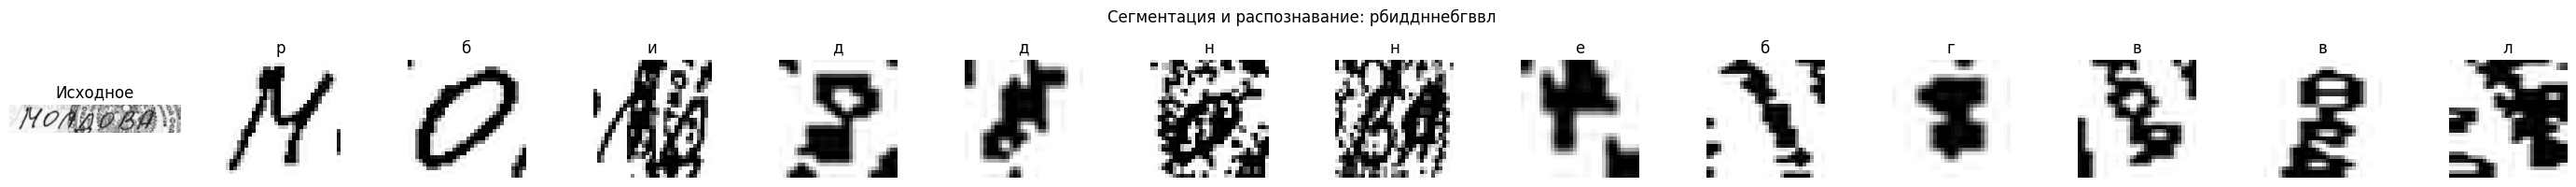


--- Обработка файла: aa1007.png ---
Распознанное слово: аюмтлавщжж


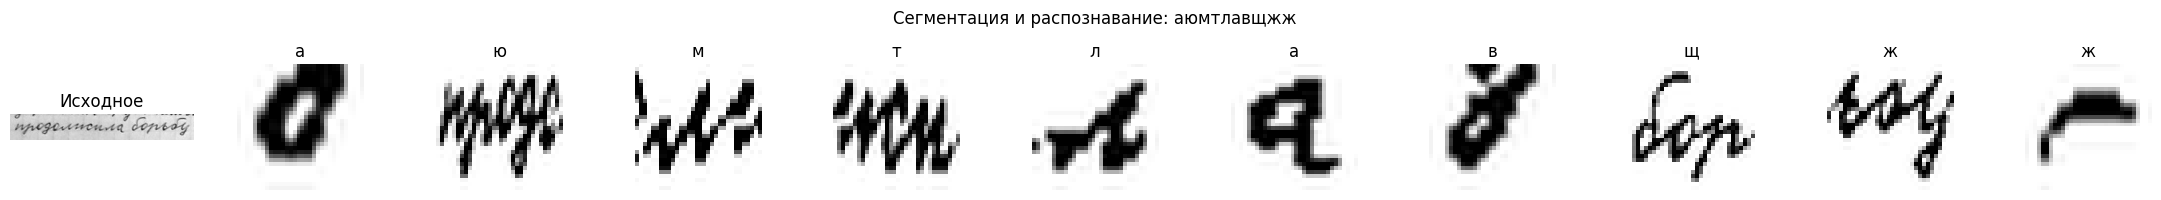


--- Обработка файла: aa101.png ---
Распознанное слово: щбоввб


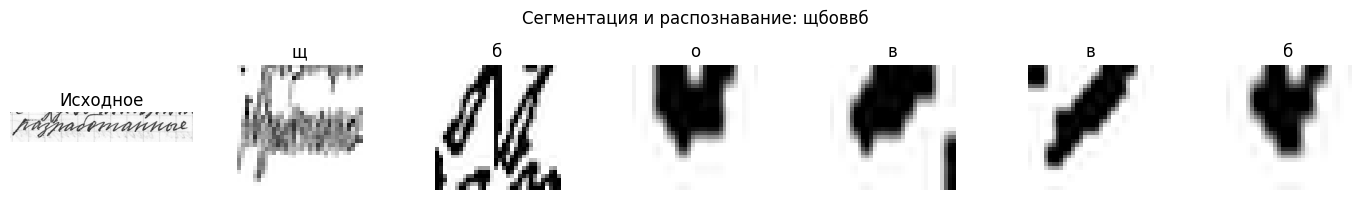


--- Обработка файла: aa1012.png ---
Распознанное слово: жщис


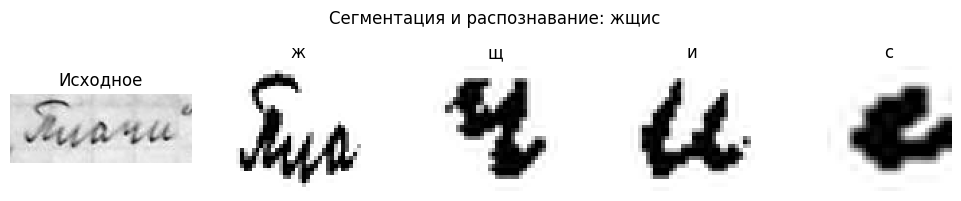


--- Обработка файла: aa1013.png ---
Распознанное слово: щмфжигтж


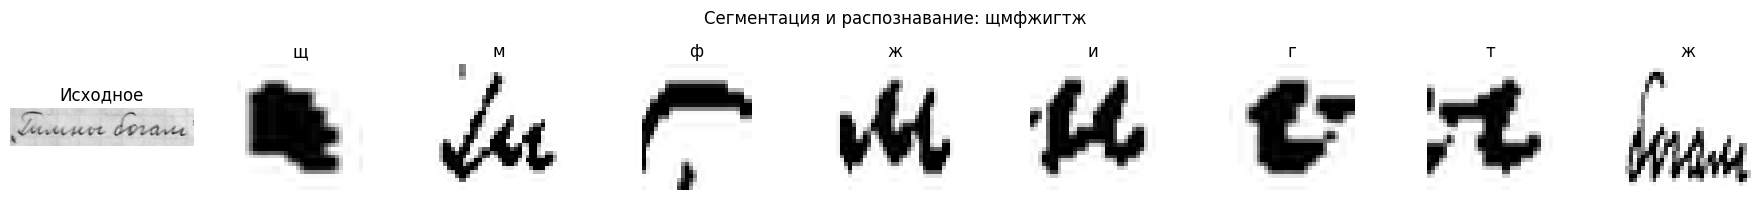

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
from sklearn.svm import SVC
from skimage.filters import threshold_otsu


RUSSIAN_LETTERS_PATH = r"russian_letters/all_letters_image/all_letters_image"
RUSSIAN_LETTERS_CSV = r"russian_letters/all_letters_info.csv"

# Читаем CSV
df_letters = pd.read_csv(RUSSIAN_LETTERS_CSV)
print("Колонки:", df_letters.columns.tolist())
print("Примеры букв (letter):", df_letters['letter'].head(10).tolist())
print("Тип данных в 'letter':", type(df_letters['letter'].iloc[0]))

X_letters, y_letters = [], []
preprocessors = [BinarizeOtsu(), CropToContent((32, 32))]
for idx, row in df_letters.iterrows():
    img_path = os.path.join(RUSSIAN_LETTERS_PATH, row['file'])
    try:
        img = Image.open(img_path)
        for p in preprocessors:
            img = p.process(img)
        img = img.convert('L').resize((32, 32))
        X_letters.append(np.array(img).flatten())
        y_letters.append(str(row['letter']))
    except Exception as e:
        print(f"Ошибка с {img_path}: {e}")

X_letters = np.array(X_letters, dtype=np.float32)
y_letters = np.array(y_letters)
print(f"Загружено {len(X_letters)} образцов, уникальных классов: {len(np.unique(y_letters))}")
print("Примеры классов (первые 10):", np.unique(y_letters)[:10])

METHOD = 'eigen'  # или 'hog'

if METHOD == 'eigen':
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_letters)
    pca = PCA(n_components=50, svd_solver='randomized', random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    clf = KNeighborsClassifier(n_neighbors=3)
    clf.fit(X_pca, y_letters)
    def predict_letter(img_flat):
        scaled = scaler.transform([img_flat])
        pcaed = pca.transform(scaled)
        return clf.predict(pcaed)[0]
else:
    def extract_hog(flat):
        img = flat.reshape(32,32).astype(np.uint8)
        fd = hog(img, orientations=9, pixels_per_cell=(7,7), cells_per_block=(2,2), visualize=False, channel_axis=None)
        return fd
    X_hog = np.array([extract_hog(x) for x in X_letters])
    scaler = StandardScaler()
    X_hog_scaled = scaler.fit_transform(X_hog)
    clf = SVC(kernel='rbf', C=10.0, random_state=42)
    clf.fit(X_hog_scaled, y_letters)
    def predict_letter(img_flat):
        hog_feat = extract_hog(img_flat)
        scaled = scaler.transform([hog_feat])
        return clf.predict(scaled)[0]

print("Классификатор обучен.")


def segment_word(image_path, target_size=(32,32)):
    img = Image.open(image_path).convert('L')
    arr = np.array(img)
    thresh = threshold_otsu(arr)
    binary = (arr > thresh).astype(np.uint8) * 255
    binary_inv = 255 - binary
    contours, _ = cv2.findContours(binary_inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])
    letters = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w < 5 or h < 5:
            continue
        pad = 2
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(binary.shape[1], x + w + pad)
        y2 = min(binary.shape[0], y + h + pad)
        letter_img = binary[y1:y2, x1:x2]
        letter_pil = Image.fromarray(letter_img)
        letter_pil = letter_pil.resize(target_size, Image.Resampling.LANCZOS)
        letter_flat = np.array(letter_pil).flatten()
        letters.append(letter_flat)
    return letters

word_folder = r"CyrillicHandwriting/train"
sample_files = [os.path.join(word_folder, f) for f in os.listdir(word_folder)[:5] if f.endswith(('.png','.jpg'))]

for fpath in sample_files:
    print(f"\n--- Обработка файла: {os.path.basename(fpath)} ---")
    letters = segment_word(fpath)
    if not letters:
        print("Буквы не найдены.")
        continue
    recognized_chars = [predict_letter(letter) for letter in letters]
    print("Распознанное слово:", ''.join(recognized_chars))
    
    # Визуализация
    fig, axes = plt.subplots(1, len(letters)+1, figsize=(2*(len(letters)+1), 2))
    img_orig = Image.open(fpath).convert('L')
    axes[0].imshow(img_orig, cmap='gray')
    axes[0].set_title('Исходное')
    axes[0].axis('off')
    for i, letter_flat in enumerate(letters):
        ax = axes[i+1]
        ax.imshow(letter_flat.reshape(32,32), cmap='gray')
        ax.set_title(recognized_chars[i])
        ax.axis('off')
    plt.suptitle(f'Сегментация и распознавание: {"".join(recognized_chars)}')
    plt.tight_layout()
    plt.show()

In [11]:
import shutil
from pathlib import Path
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

def train_and_sort_eigenfaces(pipe, output_base="sorted_images", threshold=0.5,
                              unknown_prefix="unknown"):
    X = pipe.X.astype(np.float32)
    y = pipe.y
    files = pipe.files
    classes = sorted(np.unique(y))

    # Нормализация и PCA
    X_n = X / 255.0
    n_comp = min(100, X_n.shape[1], len(y) - 1)
    pca = PCA(n_components=n_comp, svd_solver="randomized", random_state=42)
    X_p = pca.fit_transform(X_n)

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_p, y)

    out_root = Path(output_base) / pipe.dataset_name
    for cls in classes:
        (out_root / str(cls)).mkdir(parents=True, exist_ok=True)
    unknown_dir = out_root / "_unknown"
    unknown_dir.mkdir(parents=True, exist_ok=True)

    probas = knn.predict_proba(X_p)
    best_indices = np.argmax(probas, axis=1)
    confidences = np.max(probas, axis=1)
    predicted_labels = knn.classes_[best_indices]

    # Счётчики для нумерации внутри каждого класса
    class_counters = {}
    unknown_counter = 0

    total = len(files)
    print(f"Обрабатываю {total} изображений для {pipe.dataset_name}...")
    error_count = 0

    for i, img_path in enumerate(files):
        try:
            best_label = str(predicted_labels[i])
            conf = confidences[i]
            original_ext = Path(img_path).suffix

            if conf >= threshold:
                dest_dir = out_root / best_label
                # Номер для этого класса
                if best_label not in class_counters:
                    class_counters[best_label] = 1
                else:
                    class_counters[best_label] += 1
                file_num = class_counters[best_label]
                new_name = f"{best_label}_{file_num}{original_ext}"
            else:
                dest_dir = unknown_dir
                unknown_counter += 1
                new_name = f"{unknown_prefix}_{unknown_counter}{original_ext}"

            dest_path = dest_dir / new_name
            shutil.copy2(img_path, dest_path)

            if i % 200 == 0:
                print(f"  {i}/{total}")
        except Exception as e:
            if error_count < 5:
                print(f"Ошибка с {img_path}: {e}")
            error_count += 1

    if error_count:
        print(f"Всего ошибок: {error_count}")
    print(f"Готово: результаты в {out_root}")

datasets_config = {
    "ORL_faces": {
        "path": ORL_PATH,
        "max_per_class": MAX_PER_CLASS_ORL,
        "target_size": (100, 100),
        "preprocessors": None,
        "csv_file": None,
        "csv_file_col": None,
        "csv_label_col": None,
        "filename_parser": None,
    },
    "Fruits360": {
        "path": FRUITS_PATH,
        "max_per_class": MAX_PER_CLASS_FRUITS,
        "target_size": (100, 100),
        "preprocessors": None,
        "csv_file": None,
        "csv_file_col": None,
        "csv_label_col": None,
        "filename_parser": None,
    },
    "RTSD": {
        "path": RTSD_PATH,
        "max_per_class": MAX_PER_CLASS_RTSD,
        "target_size": (100, 100),
        "preprocessors": None,
        "csv_file": None,
        "csv_file_col": None,
        "csv_label_col": None,
        "filename_parser": None,
    },
    "MathSymbols": {
        "path": MATH_SYMBOLS_PATH,
        "max_per_class": None,
        "target_size": (45, 45),
        "preprocessors": [BinarizeOtsu(), CropToContent((45, 45))],
        "csv_file": None,
        "csv_file_col": None,
        "csv_label_col": None,
        "filename_parser": None,
    },
    "Digits": {
        "path": DIGITS_PATH,
        "max_per_class": None,
        "target_size": (28, 28),
        "preprocessors": [BinarizeOtsu(), CropToContent((28, 28))],
        "csv_file": None,
        "csv_file_col": None,
        "csv_label_col": None,
        "filename_parser": None,
    },
    "RussianLetters": {
        "path": RUSSIAN_LETTERS_PATH,
        "max_per_class": None,
        "target_size": (32, 32),
        "preprocessors": [BinarizeOtsu(), CropToContent((32, 32))],
        "csv_file": RUSSIAN_LETTERS_CSV,
        "csv_file_col": 'file',
        "csv_label_col": 'label',
        "filename_parser": None,
    },
}

def parse_digits_filename(path):
    name = os.path.basename(path)
    if '\\' in name:
        return name.split('\\')[0]
    import re
    m = re.match(r'([A-Za-z0-9]+)', name)
    return m.group(1) if m else None

datasets_config["Digits"]["filename_parser"] = parse_digits_filename

for name, cfg in datasets_config.items():
    print(f"\n=== Обработка датасета: {name} ===")
    pipe = ImageExperimentPipeline(
        dataset_name=name,
        dataset_path=cfg["path"],
        target_size=cfg["target_size"],
        gray=GRAY,
        max_per_class=cfg["max_per_class"],
        preprocessors=cfg["preprocessors"],
        csv_file=cfg["csv_file"],
        csv_file_col=cfg["csv_file_col"],
        csv_label_col=cfg["csv_label_col"],
        filename_parser=cfg["filename_parser"],
    )
    pipe.load_dataset_only(verbose=True)
    train_and_sort_eigenfaces(pipe, output_base="sorted_images", threshold=0.5)


=== Обработка датасета: ORL_faces ===


## Dataset: ORL_faces (raw) - samples 400 classes 40

Обрабатываю 400 изображений для ORL_faces...
  0/400
  200/400
Готово: результаты в sorted_images\ORL_faces

=== Обработка датасета: Fruits360 ===


## Dataset: Fruits360 (raw) - samples 7509 classes 251

Обрабатываю 7509 изображений для Fruits360...
  0/7509
  200/7509
  400/7509
  600/7509
  800/7509
  1000/7509
  1200/7509
  1400/7509
  1600/7509
  1800/7509
  2000/7509
  2200/7509
  2400/7509
  2600/7509
  2800/7509
  3000/7509
  3200/7509
  3400/7509
  3600/7509
  3800/7509
  4000/7509
  4200/7509
  4400/7509
  4600/7509
  4800/7509
  5000/7509
  5200/7509
  5400/7509
  5600/7509
  5800/7509
  6000/7509
  6200/7509
  6400/7509
  6600/7509
  6800/7509
  7000/7509
  7200/7509
  7400/7509
Готово: результаты в sorted_images\Fruits360

=== Обработка датасета: RTSD ===


...

Обрабатываю 23761 изображений для MathSymbols...
  0/23761
  200/23761
  400/23761
  600/23761
  800/23761
  1000/23761
  1200/23761
  1400/23761
  1600/23761
  1800/23761
  2000/23761
  2200/23761
  2400/23761
  2600/23761
  2800/23761
  3000/23761
  3200/23761
  3400/23761
  3600/23761
  3800/23761
  4000/23761
  4200/23761
  4400/23761
  4600/23761
  4800/23761
  5000/23761
  5200/23761
  5400/23761
  5600/23761
  5800/23761
  6000/23761
  6200/23761
  6400/23761
  6600/23761
  6800/23761
  7000/23761
  7200/23761
  7400/23761
  7600/23761
  7800/23761
  8000/23761
  8200/23761
  8400/23761
  8600/23761
  8800/23761
  9000/23761
  9200/23761
  9400/23761
  9600/23761
  9800/23761
  10000/23761
  10200/23761
  10400/23761
  10600/23761
  10800/23761
  11000/23761
  11200/23761
  11400/23761
  11600/23761
  11800/23761
  12000/23761
  12200/23761
  12400/23761
  12600/23761
  12800/23761
  13000/23761
  13200/23761
  13400/23761
  13600/23761
  13800/23761
  14000/23761
  14200/23761


## Dataset: Digits (raw) - samples 6820 classes 62

Обрабатываю 6820 изображений для Digits...
  0/6820
  200/6820
  400/6820
  600/6820
  800/6820
  1000/6820
  1200/6820
  1400/6820
  1600/6820
  1800/6820
  2000/6820
  2200/6820
  2400/6820
  2600/6820
  2800/6820
  3000/6820
  3200/6820
  3400/6820
  3600/6820
  3800/6820
  4000/6820
  4200/6820
  4400/6820
  4600/6820
  4800/6820
  5000/6820
  5200/6820
  5400/6820
  5600/6820
  5800/6820
  6000/6820
  6200/6820
  6400/6820
  6600/6820
  6800/6820
Готово: результаты в sorted_images\Digits

=== Обработка датасета: RussianLetters ===


## Dataset: RussianLetters (raw) - samples 14136 classes 33

Обрабатываю 14136 изображений для RussianLetters...
  0/14136
  200/14136
  400/14136
  600/14136
  800/14136
  1000/14136
  1200/14136
  1400/14136
  1600/14136
  1800/14136
  2000/14136
  2200/14136
  2400/14136
  2600/14136
  2800/14136
  3000/14136
  3200/14136
  3400/14136
  3600/14136
  3800/14136
  4000/14136
  4200/14136
  4400/14136
  4600/14136
  4800/14136
  5000/14136
  5200/14136
  5400/14136
  5600/14136
  5800/14136
  6000/14136
  6200/14136
  6400/14136
  6600/14136
  6800/14136
  7000/14136
  7200/14136
  7400/14136
  7600/14136
  7800/14136
  8000/14136
  8200/14136
  8400/14136
  8600/14136
  8800/14136
  9000/14136
  9200/14136
  9400/14136
  9600/14136
  9800/14136
  10000/14136
  10200/14136
  10400/14136
  10600/14136
  10800/14136
  11000/14136
  11200/14136
  11400/14136
  11600/14136
  11800/14136
  12000/14136
  12200/14136
  12400/14136
  12600/14136
  12800/14136
  13000/14136
  13200/14136
  13400/14136
  13600/14136
  13800/14136
  14000/14136
Готово: рез

In [12]:
# Ячейка: Экспорт ONNX-моделей
import json
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

def parse_digits_filename(path):
    name = os.path.basename(path)
    if '\\' in name:
        return name.split('\\')[0]
    import re
    m = re.match(r'([A-Za-z0-9]+)', name)
    return m.group(1) if m else None

def export_eigenfaces_onnx(pipe, onnx_path="eigenfaces_model.onnx",
                           pca_n_components=None, knn_neighbors=3):
    X = pipe.X.astype(np.float32) / 255.0
    y = pipe.y
    classes = sorted(np.unique(y))
    label_to_idx = {c: i for i, c in enumerate(classes)}
    y_idx = np.array([label_to_idx[lab] for lab in y])

    if pca_n_components is None:
        pca_n_components = min(100, X.shape[1], len(y) - 1)

    n_comp = pca_n_components
    pipeline = Pipeline([
        ("pca", PCA(n_components=n_comp, svd_solver="randomized", random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=knn_neighbors))
    ])
    pipeline.fit(X, y_idx)

    # Экспорт ONNX
    initial_type = [("input", FloatTensorType([None, X.shape[1]]))]
    onx = convert_sklearn(pipeline, initial_types=initial_type,
                          options={KNeighborsClassifier: {'zipmap': False}})

    with open(onnx_path, "wb") as f:
        f.write(onx.SerializeToString())

    # Сохраняем имена классов
    classes_path = onnx_path.replace(".onnx", "_classes.txt")
    with open(classes_path, "w", encoding="utf-8") as f:
        f.write("\n".join(str(cls) for cls in classes))

    # Сохраняем метаданные (размер, число компонент, k) в JSON
    meta = {
        "target_size": list(pipe.target_size),
        "pca_n_components": n_comp,
        "knn_neighbors": knn_neighbors,
    }
    meta_path = onnx_path.replace(".onnx", ".onnx.json")
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"ONNX модель сохранена в {onnx_path}")
    print(f"  классы: {classes_path}")
    print(f"  метаданные: {meta_path}")

datasets_config = {
    "ORL_faces": {
        "path": ORL_PATH,
        "max_per_class": MAX_PER_CLASS_ORL,
        "target_size": (100, 100),
        "preprocessors": None,
        "csv_file": None,
        "csv_file_col": None,
        "csv_label_col": None,
        "filename_parser": None,
        "pca_components": 100,
        "knn_neighbors": 3,
    },
    "Fruits360": {
        "path": FRUITS_PATH,
        "max_per_class": MAX_PER_CLASS_FRUITS,
        "target_size": (100, 100),
        "preprocessors": None,
        "csv_file": None,
        "csv_file_col": None,
        "csv_label_col": None,
        "filename_parser": None,
        "pca_components": 100,
        "knn_neighbors": 3,
    },
    "RTSD": {
        "path": RTSD_PATH,
        "max_per_class": MAX_PER_CLASS_RTSD,
        "target_size": (100, 100),
        "preprocessors": None,
        "csv_file": None,
        "csv_file_col": None,
        "csv_label_col": None,
        "filename_parser": None,
        "pca_components": 100,
        "knn_neighbors": 3,
    },
    "MathSymbols": {
        "path": MATH_SYMBOLS_PATH,
        "max_per_class": None,
        "target_size": (45, 45),
        "preprocessors": [BinarizeOtsu(), CropToContent((45, 45))],
        "csv_file": None,
        "csv_file_col": None,
        "csv_label_col": None,
        "filename_parser": None,
        "pca_components": 50,
        "knn_neighbors": 3,
    },
    "Digits": {
        "path": DIGITS_PATH,
        "max_per_class": None,
        "target_size": (28, 28),
        "preprocessors": [BinarizeOtsu(), CropToContent((28, 28))],
        "csv_file": None,
        "csv_file_col": None,
        "csv_label_col": None,
        "filename_parser": parse_digits_filename,
        "pca_components": 30,
        "knn_neighbors": 3,
    },
    "RussianLetters": {
        "path": RUSSIAN_LETTERS_PATH,
        "max_per_class": None,
        "target_size": (32, 32),
        "preprocessors": [BinarizeOtsu(), CropToContent((32, 32))],
        "csv_file": RUSSIAN_LETTERS_CSV,
        "csv_file_col": 'file',
        "csv_label_col": 'label',
        "filename_parser": None,
        "pca_components": 100,
        "knn_neighbors": 3,
    },
}

for name, cfg in datasets_config.items():
    print(f"\n=== Экспорт ONNX для {name} ===")
    pipe = ImageExperimentPipeline(
        dataset_name=name,
        dataset_path=cfg["path"],
        target_size=cfg["target_size"],
        gray=GRAY,
        max_per_class=cfg["max_per_class"],
        preprocessors=cfg["preprocessors"],
        csv_file=cfg["csv_file"],
        csv_file_col=cfg["csv_file_col"],
        csv_label_col=cfg["csv_label_col"],
        filename_parser=cfg["filename_parser"],
    )
    pipe.load_dataset_only(verbose=True)

    onnx_filename = f"{name.lower()}_eigenfaces.onnx"
    export_eigenfaces_onnx(
        pipe,
        onnx_path=onnx_filename,
        pca_n_components=cfg["pca_components"],
        knn_neighbors=cfg["knn_neighbors"],
    )


=== Экспорт ONNX для ORL_faces ===


## Dataset: ORL_faces (raw) - samples 400 classes 40

ONNX модель сохранена в orl_faces_eigenfaces.onnx
  классы: orl_faces_eigenfaces_classes.txt
  метаданные: orl_faces_eigenfaces.onnx.json

=== Экспорт ONNX для Fruits360 ===


## Dataset: Fruits360 (raw) - samples 7509 classes 251

ONNX модель сохранена в fruits360_eigenfaces.onnx
  классы: fruits360_eigenfaces_classes.txt
  метаданные: fruits360_eigenfaces.onnx.json

=== Экспорт ONNX для RTSD ===


...

ONNX модель сохранена в mathsymbols_eigenfaces.onnx
  классы: mathsymbols_eigenfaces_classes.txt
  метаданные: mathsymbols_eigenfaces.onnx.json

=== Экспорт ONNX для Digits ===


## Dataset: Digits (raw) - samples 6820 classes 62

ONNX модель сохранена в digits_eigenfaces.onnx
  классы: digits_eigenfaces_classes.txt
  метаданные: digits_eigenfaces.onnx.json

=== Экспорт ONNX для RussianLetters ===


## Dataset: RussianLetters (raw) - samples 14136 classes 33

ONNX модель сохранена в russianletters_eigenfaces.onnx
  классы: russianletters_eigenfaces_classes.txt
  метаданные: russianletters_eigenfaces.onnx.json


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

DATASETS = {
    'urbansound8k': {
        'path': r'UrbanSound8K',
        'type': 'urbansound'
    },
    'vehicle_sound': {
        'path': r'vehicle_type_sound_dataset',
        'type': 'vehicle'
    },
    'drone_sound': {
        'path': r'Binary_Drone_Audio/',
        'type': 'drone'
    }
}


def extract_mfcc(file_path, n_mfcc=13, duration=3.0, sr=22050):
    try:
        audio, sr = librosa.load(file_path, sr=sr, duration=duration)
        if len(audio) < sr * duration:
            audio = np.pad(audio, (0, int(sr * duration) - len(audio)))
        else:
            audio = audio[:int(sr * duration)]
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfcc, axis=1)
    except Exception as e:
        print(f"Ошибка при обработке {file_path}: {e}")
        return None

def load_dataset_by_type(dataset_path, dataset_type, max_files_per_class=None):
    X, y = [], []
    if dataset_type == 'urbansound':
        csv_path = os.path.join(dataset_path, 'UrbanSound8K.csv')
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Не найден файл {csv_path}")
        df = pd.read_csv(csv_path)
        for idx, row in df.iterrows():
            fold = row['fold']
            file_name = row['slice_file_name']
            class_name = row['class']
            # Аудиофайлы лежат в папках foldX прямо в корне
            file_path = os.path.join(dataset_path, f'fold{fold}', file_name)
            if not os.path.exists(file_path):
                continue
            if max_files_per_class is not None:
                if y.count(class_name) >= max_files_per_class:
                    continue
            mfcc = extract_mfcc(file_path)
            if mfcc is not None:
                X.append(mfcc)
                y.append(class_name)
        return np.array(X), np.array(y)

    elif dataset_type == 'vehicle':
        classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
        for cls in classes:
            cls_path = os.path.join(dataset_path, cls)
            files = glob.glob(os.path.join(cls_path, '*.wav')) + glob.glob(os.path.join(cls_path, '*.mp3'))
            if max_files_per_class is not None:
                files = files[:max_files_per_class]
            for f in files:
                mfcc = extract_mfcc(f)
                if mfcc is not None:
                    X.append(mfcc)
                    y.append(cls)
        return np.array(X), np.array(y)

    elif dataset_type == 'drone':
        classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
        for cls in classes:
            cls_path = os.path.join(dataset_path, cls)
            files = glob.glob(os.path.join(cls_path, '*.wav')) + glob.glob(os.path.join(cls_path, '*.mp3'))
            if max_files_per_class is not None:
                files = files[:max_files_per_class]
            for f in files:
                mfcc = extract_mfcc(f)
                if mfcc is not None:
                    X.append(mfcc)
                    y.append(cls)
        return np.array(X), np.array(y)

    else:
        raise ValueError(f"Неизвестный тип датасета: {dataset_type}")


MAX_PER_CLASS = None

all_results = []

for ds_name, config in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"Обработка датасета: {ds_name}")
    print(f"{'='*60}")

    try:
        X, y = load_dataset_by_type(config['path'], config['type'], max_files_per_class=MAX_PER_CLASS)
    except FileNotFoundError as e:
        print(f"Ошибка: {e}. Пропускаем датасет.")
        continue

    if len(X) == 0:
        print("Нет загруженных файлов. Пропускаем.")
        continue

    print(f"Загружено {len(X)} образцов, классов: {np.unique(y)}")

    # Разделение
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"Точность на тесте: {acc:.4f}")
    print("\nОтчёт по классификации:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f'Матрица ошибок для {ds_name}')
    plt.xlabel('Предсказано')
    plt.ylabel('Истина')
    plt.show()

    all_results.append({
        'dataset': ds_name,
        'accuracy': acc,
        'n_samples': len(X),
        'n_classes': len(np.unique(y))
    })


if all_results:
    df_results = pd.DataFrame(all_results)
    print("\n=== Сводка по всем датасетам ===")
    print(df_results.to_string(index=False))
else:
    print("Нет результатов для отображения.")


# ДЕМОНСТРАЦИЯ СПЕКТРОГРАММЫ
sample_file = None
for ds_name, config in DATASETS.items():
    for root, dirs, files in os.walk(config['path']):
        for f in files:
            if f.endswith(('.wav', '.mp3')):
                sample_file = os.path.join(root, f)
                break
        if sample_file:
            break
    if sample_file:
        break

if sample_file:
    print(f"\nПоказана спектрограмма файла: {sample_file}")
    audio, sr = librosa.load(sample_file, sr=22050, duration=3.0)
    plt.figure(figsize=(10,4))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Спектрограмма: {os.path.basename(sample_file)}')
    plt.tight_layout()
    plt.show()
else:
    print("Не найдено ни одного аудиофайла для демонстрации.")


# СИМУЛЯЦИЯ TDOA-ЛОКАЛИЗАЦИИ
from scipy.optimize import minimize

def simulate_tdoa_localization():
    speed_sound = 343.0
    mic_positions = np.array([[0,0],[1,0],[0,1],[1,1]])
    x_src, y_src = 2.0, 1.5
    distances = np.sqrt((mic_positions[:,0]-x_src)**2 + (mic_positions[:,1]-y_src)**2)
    times = distances / speed_sound
    ref_time = times[0]
    tdoa = times - ref_time

    def error_func(pos, mic_pos, tdoa, speed):
        dist = np.sqrt((mic_pos[:,0]-pos[0])**2 + (mic_pos[:,1]-pos[1])**2)
        times_theor = dist / speed
        tdoa_theor = times_theor - times_theor[0]
        return np.sum((tdoa_theor - tdoa)**2)

    x0 = np.mean(mic_positions[:,0])
    y0 = np.mean(mic_positions[:,1])
    res = minimize(error_func, [x0, y0], args=(mic_positions, tdoa, speed_sound), method='Nelder-Mead')
    estimated_pos = res.x

    print("\n=== Симуляция локации источника звука ===")
    print(f"Истинное положение: ({x_src:.2f}, {y_src:.2f})")
    print(f"Оценённое положение: ({estimated_pos[0]:.2f}, {estimated_pos[1]:.2f})")
    print(f"Ошибка: {np.linalg.norm(estimated_pos - np.array([x_src, y_src])):.3f} м")

    plt.figure(figsize=(6,6))
    plt.scatter(mic_positions[:,0], mic_positions[:,1], c='blue', label='Микрофоны', s=100)
    plt.scatter(x_src, y_src, c='red', label='Истинный источник', s=100)
    plt.scatter(estimated_pos[0], estimated_pos[1], c='green', marker='x', s=200, label='Оценённый источник')
    plt.xlim(-1, 4)
    plt.ylim(-1, 4)
    plt.grid(True)
    plt.legend()
    plt.title('Демонстрация TDOA-локализации')
    plt.xlabel('X (м)')
    plt.ylabel('Y (м)')
    plt.show()

simulate_tdoa_localization()

print("\n Акустический пайплайн (все датасеты) завершён.")


Обработка датасета: urbansound8k
Загружено 8732 образцов, классов: ['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']


NameError: name 'StandardScaler' is not defined

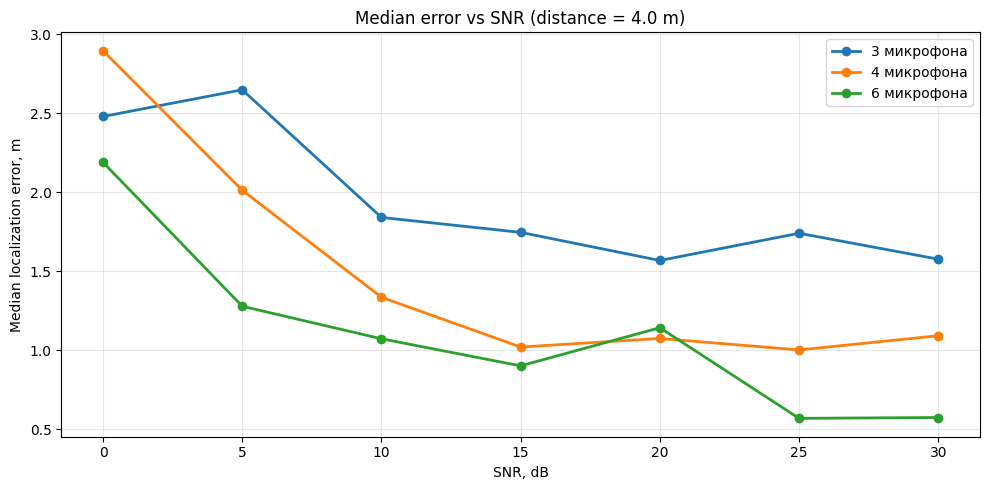

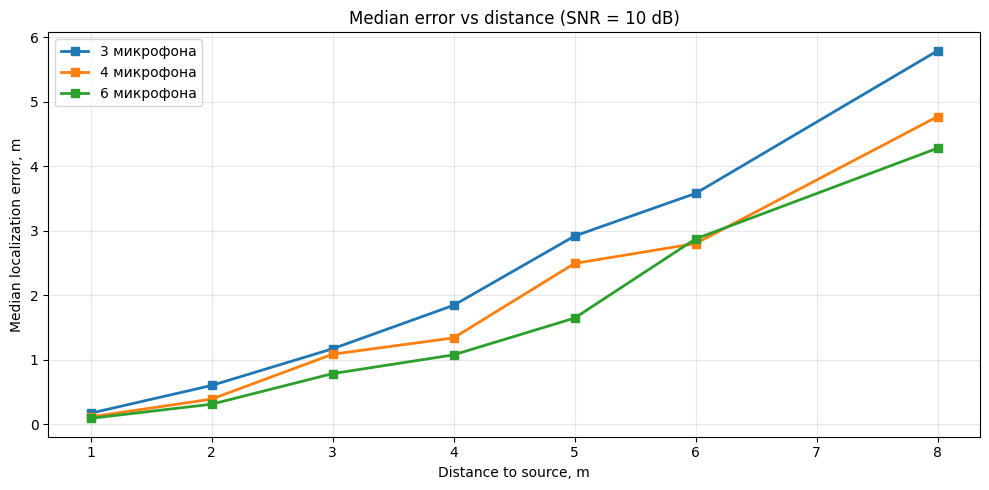

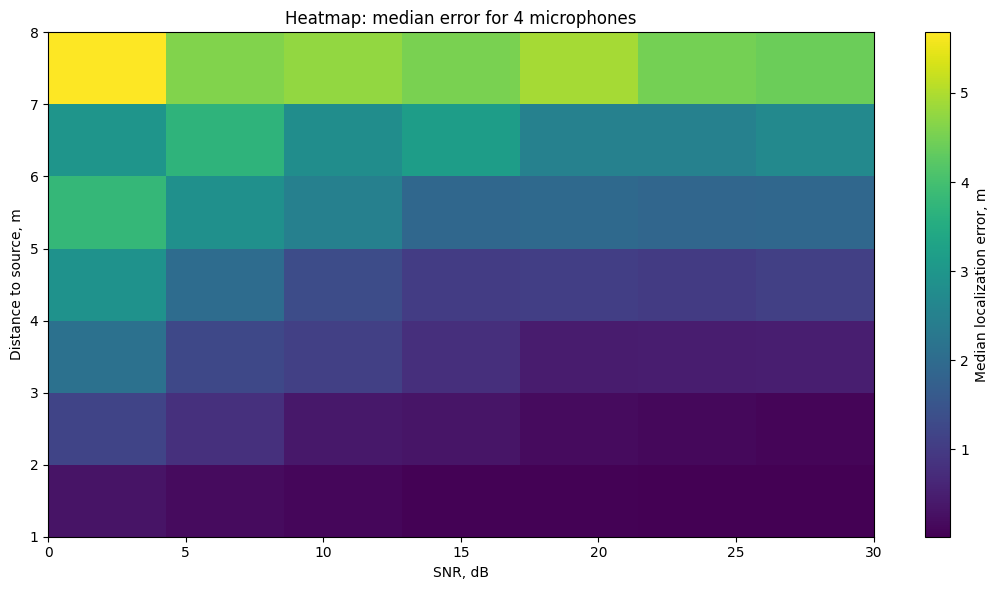


=== Summary by microphone count ===


,mean_error_m,median_error_m,p90_error_m,success_rate
n_mics,,,,
3,2.3666,2.2860,3.5263,1.0
4,1.8693,1.8684,2.9814,1.0
6,1.5347,1.4452,2.4478,1.0



=== Median error at fixed distance = 4 m ===


n_mics,3,4,6
snr_db,,,
0.0,2.4809,2.8972,2.1908
5.0,2.6500,2.0141,1.2798
10.0,1.8420,1.3368,1.0738
15.0,1.7475,1.0217,0.9026
20.0,1.5695,1.0762,1.1439
25.0,1.7419,1.0033,0.5704
30.0,1.5778,1.0933,0.5756



=== Median error at fixed SNR = 10 dB ===


n_mics,3,4,6
distance_m,,,
1.0,0.1691,0.1112,0.0897
2.0,0.5992,0.3878,0.3086
3.0,1.1680,1.0836,0.7830
4.0,1.8420,1.3368,1.0738
5.0,2.9160,2.4915,1.6441
6.0,3.5774,2.8002,2.8721
8.0,5.7892,4.7688,4.2783


In [27]:
# СИНТЕТИЧЕСКАЯ СИМУЛЯЦИЯ TDOA-ЛОКАЛИЗАЦИИ (Ячейкой ниже на реальных данных)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

np.random.seed(42)

SPEED_OF_SOUND = 343.0
ARRAY_RADIUS = 0.5
MIC_COUNTS = [3, 4, 6]
DISTANCES = np.array([1, 2, 3, 4, 5, 6, 8], dtype=float)
SNR_DB_VALUES = np.array([0, 5, 10, 15, 20, 25, 30], dtype=float)

ANGLE_SAMPLES = np.linspace(0, 2 * np.pi, 8, endpoint=False)
NOISE_REPEATS = 5

BASE_TDOA_STD_AT_0DB = 180e-6 
REFERENCE_MIC = 0

def build_microphone_array(n_mics, radius=ARRAY_RADIUS):
    # Размещаем микрофоны по окружности
    angles = np.linspace(0, 2 * np.pi, n_mics, endpoint=False)
    return np.column_stack((radius * np.cos(angles), radius * np.sin(angles)))

def tdoa_from_source(source_pos, mic_pos):
    # TDOA относительно первого микрофона
    distances = np.linalg.norm(mic_pos - source_pos, axis=1)
    times = distances / SPEED_OF_SOUND
    return times - times[REFERENCE_MIC]

def simulate_tdoa_measurement(source_pos, mic_pos, snr_db):
    # Добавляем шум к TDOA; чем выше SNR, тем меньше шум
    tdoa_true = tdoa_from_source(source_pos, mic_pos)
    noise_std = BASE_TDOA_STD_AT_0DB * 10 ** (-snr_db / 20)
    noise = np.random.normal(0.0, noise_std, size=tdoa_true.shape)
    noise[REFERENCE_MIC] = 0.0
    return tdoa_true + noise

def estimate_source_position(mic_pos, measured_tdoa):
    # Оцениваем положение источника по TDOA через least-squares
    def residuals(pos):
        return tdoa_from_source(pos, mic_pos) - measured_tdoa

    x0 = np.array([0.0, 0.0], dtype=float)
    result = least_squares(
        residuals,
        x0,
        method="trf",
        max_nfev=200,
    )
    return result.x, result.success

def run_one_trial(n_mics, distance, snr_db, angle):
    mic_pos = build_microphone_array(n_mics)
    source_pos = np.array([distance * np.cos(angle), distance * np.sin(angle)])

    measured_tdoa = simulate_tdoa_measurement(source_pos, mic_pos, snr_db)
    estimated_pos, success = estimate_source_position(mic_pos, measured_tdoa)
    error_m = np.linalg.norm(estimated_pos - source_pos)

    return error_m, success

records = []

for n_mics in MIC_COUNTS:
    for distance in DISTANCES:
        for snr_db in SNR_DB_VALUES:
            errors = []
            successes = 0
            for angle in ANGLE_SAMPLES:
                for _ in range(NOISE_REPEATS):
                    error_m, success = run_one_trial(n_mics, distance, snr_db, angle)
                    errors.append(error_m)
                    successes += int(success)

            errors = np.asarray(errors, dtype=float)
            records.append({
                "n_mics": n_mics,
                "distance_m": distance,
                "snr_db": snr_db,
                "mean_error_m": float(errors.mean()),
                "median_error_m": float(np.median(errors)),
                "p90_error_m": float(np.percentile(errors, 90)),
                "success_rate": successes / len(errors),
            })

df_tdoa = pd.DataFrame(records)


# График 1: ошибка vs SNR при фиксированном расстоянии
fixed_distance = 4.0
subset_fixed_dist = df_tdoa[np.isclose(df_tdoa["distance_m"], fixed_distance)]

plt.figure(figsize=(10, 5))
for n_mics in MIC_COUNTS:
    part = subset_fixed_dist[subset_fixed_dist["n_mics"] == n_mics].sort_values("snr_db")
    plt.plot(
        part["snr_db"],
        part["median_error_m"],
        marker="o",
        linewidth=2,
        label=f"{n_mics} микрофона",
    )

plt.title(f"Median error vs SNR (distance = {fixed_distance:.1f} m)")
plt.xlabel("SNR, dB")
plt.ylabel("Median localization error, m")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# График 2: ошибка vs расстояние при фиксированном SNR
fixed_snr = 10.0
subset_fixed_snr = df_tdoa[np.isclose(df_tdoa["snr_db"], fixed_snr)]

plt.figure(figsize=(10, 5))
for n_mics in MIC_COUNTS:
    part = subset_fixed_snr[subset_fixed_snr["n_mics"] == n_mics].sort_values("distance_m")
    plt.plot(
        part["distance_m"],
        part["median_error_m"],
        marker="s",
        linewidth=2,
        label=f"{n_mics} микрофона",
    )

plt.title(f"Median error vs distance (SNR = {fixed_snr:.0f} dB)")
plt.xlabel("Distance to source, m")
plt.ylabel("Median localization error, m")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

heatmap_mics = 4
heatmap_df = df_tdoa[df_tdoa["n_mics"] == heatmap_mics]
heatmap = heatmap_df.pivot(index="distance_m", columns="snr_db", values="median_error_m").sort_index()

plt.figure(figsize=(11, 6))
im = plt.imshow(
    heatmap.values,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    extent=[
        float(heatmap.columns.min()),
        float(heatmap.columns.max()),
        float(heatmap.index.min()),
        float(heatmap.index.max()),
    ],
)
plt.colorbar(im, label="Median localization error, m")
plt.title(f"Heatmap: median error for {heatmap_mics} microphones")
plt.xlabel("SNR, dB")
plt.ylabel("Distance to source, m")
plt.tight_layout()
plt.show()

print("\n=== Summary by microphone count ===")
summary = (
    df_tdoa.groupby("n_mics")
    .agg(
        mean_error_m=("mean_error_m", "mean"),
        median_error_m=("median_error_m", "mean"),
        p90_error_m=("p90_error_m", "mean"),
        success_rate=("success_rate", "mean"),
    )
    .round(4)
)
display(summary)

print("\n=== Median error at fixed distance = 4 m ===")
display(
    subset_fixed_dist.pivot(
        index="snr_db",
        columns="n_mics",
        values="median_error_m",
    ).round(4)
)

print("\n=== Median error at fixed SNR = 10 dB ===")
display(
    subset_fixed_snr.pivot(
        index="distance_m",
        columns="n_mics",
        values="median_error_m",
    ).round(4)
)

Audio dir   : STARSS22\dummy\clips\dummy_data\foa_dev
Metadata dir: STARSS22\dummy\clips\dummy_data\metadata_dev
Найдено пар audio+csv: 121


,clip,audio_path,csv_path,n_annotations,n_classes
0,fold4_room23_mix001,STARSS22\dummy\clips\dummy_data\foa_dev\dev-te...,STARSS22\dummy\clips\dummy_data\metadata_dev\d...,1846,5
1,fold4_room23_mix002,STARSS22\dummy\clips\dummy_data\foa_dev\dev-te...,STARSS22\dummy\clips\dummy_data\metadata_dev\d...,1006,5
2,fold4_room23_mix003,STARSS22\dummy\clips\dummy_data\foa_dev\dev-te...,STARSS22\dummy\clips\dummy_data\metadata_dev\d...,1267,3
3,fold4_room23_mix004,STARSS22\dummy\clips\dummy_data\foa_dev\dev-te...,STARSS22\dummy\clips\dummy_data\metadata_dev\d...,3070,7
4,fold4_room23_mix005,STARSS22\dummy\clips\dummy_data\foa_dev\dev-te...,STARSS22\dummy\clips\dummy_data\metadata_dev\d...,812,3
5,fold4_room23_mix006,STARSS22\dummy\clips\dummy_data\foa_dev\dev-te...,STARSS22\dummy\clips\dummy_data\metadata_dev\d...,1969,5
6,fold4_room23_mix007,STARSS22\dummy\clips\dummy_data\foa_dev\dev-te...,STARSS22\dummy\clips\dummy_data\metadata_dev\d...,1211,5
7,fold4_room23_mix008,STARSS22\dummy\clips\dummy_data\foa_dev\dev-te...,STARSS22\dummy\clips\dummy_data\metadata_dev\d...,759,2
8,fold4_room23_mix009,STARSS22\dummy\clips\dummy_data\foa_dev\dev-te...,STARSS22\dummy\clips\dummy_data\metadata_dev\d...,1234,2
9,fold4_room23_mix010,STARSS22\dummy\clips\dummy_data\foa_dev\dev-te...,STARSS22\dummy\clips\dummy_data\metadata_dev\d...,779,5



=== Общая сводка ===
Кол-во клипов для demo baseline: 121
Кол-во аннотаций: 222980
Уникальных классов: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


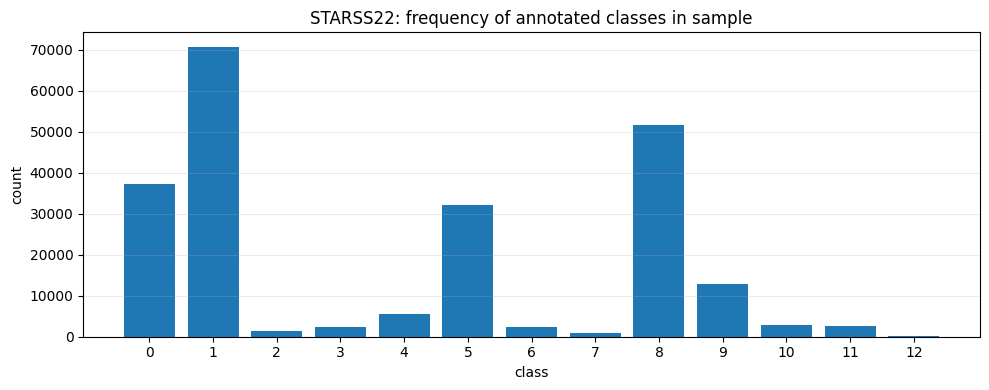

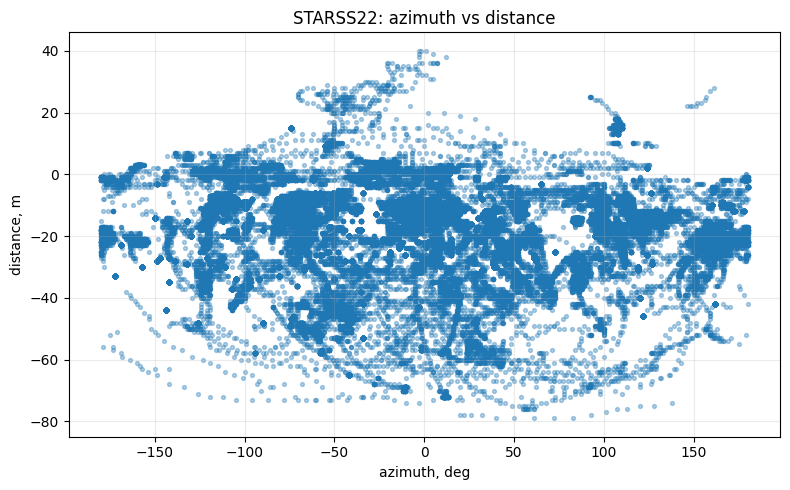

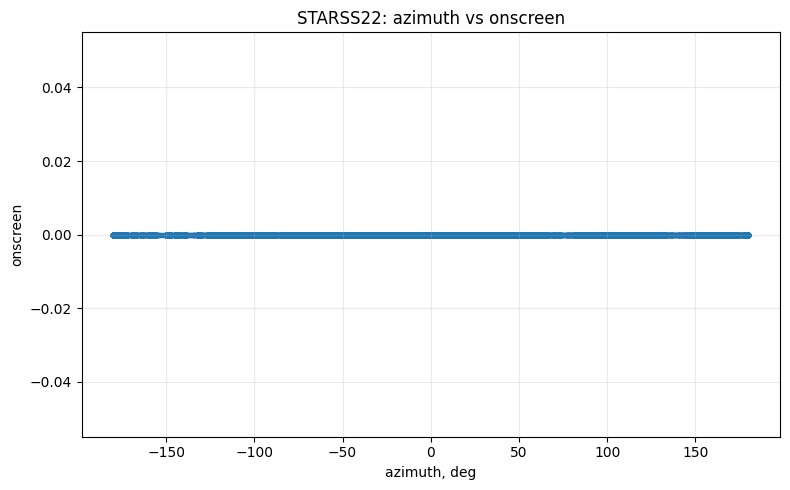


Demo clip: fold4_room23_mix001.wav
audio shape: (4, 1456800) sr: 24000
annotation rows: 1846


,frame,class,source,azimuth,distance,onscreen
0,1,8,0,14.0,0.0,0
1,1,5,0,-37.0,-18.0,0
2,2,8,0,14.0,0.0,0
3,2,1,1,-88.0,2.0,0
4,2,5,0,-37.0,-18.0,0
5,3,1,1,-75.0,3.0,0
6,3,5,0,-37.0,-18.0,0
7,3,8,0,14.0,0.0,0
8,4,8,0,14.0,0.0,0
9,4,1,1,-62.0,4.0,0


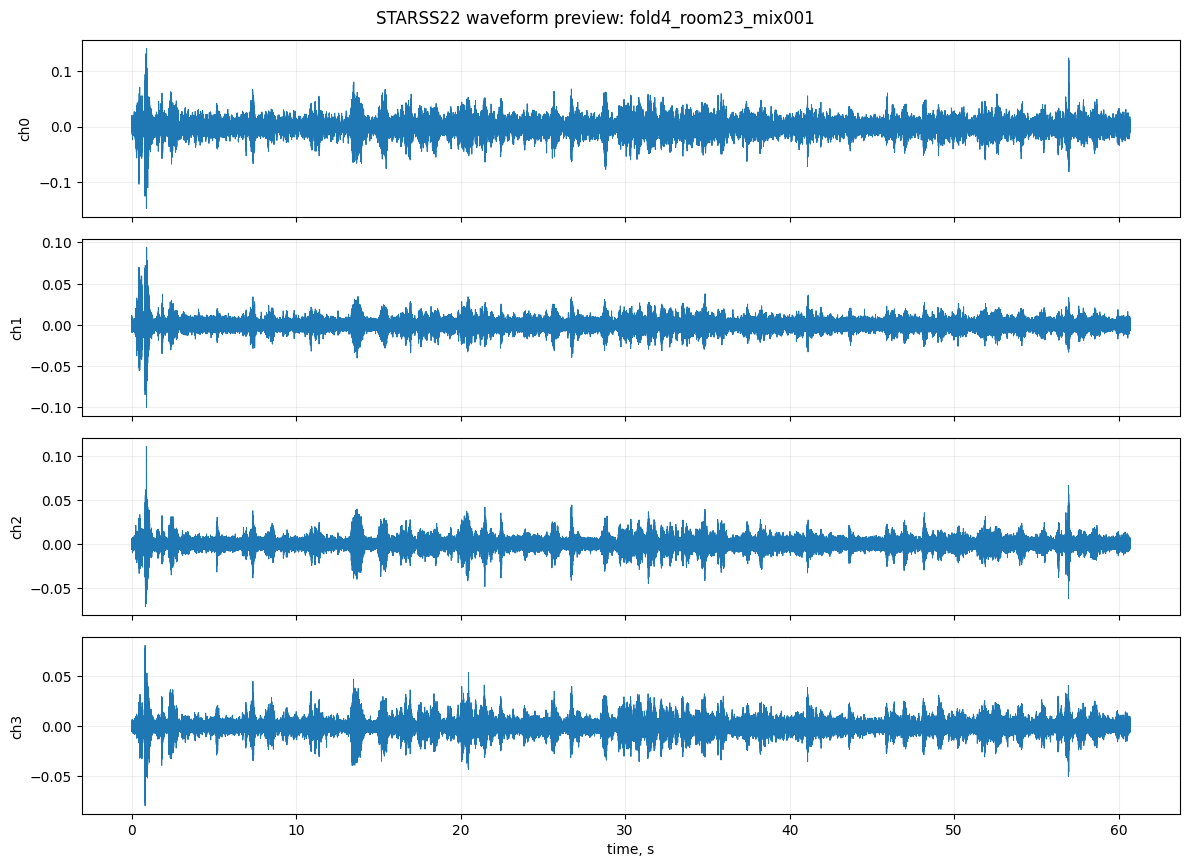

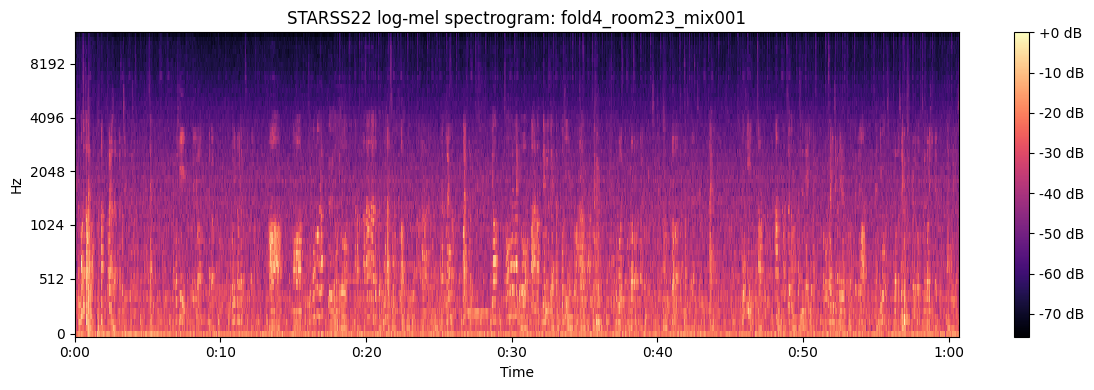


Baseline dataset:
X shape: (121, 512)
Y shape: (121, 13)

=== Baseline result ===
macro average precision: 0.7407

Classification report:
              precision    recall  f1-score   support

     class_0       0.86      0.92      0.89        13
     class_1       0.93      1.00      0.96        27
     class_2       0.44      0.67      0.53         6
     class_3       0.62      0.50      0.56        10
     class_4       0.75      0.90      0.82        20
     class_5       0.71      0.91      0.80        11
     class_6       0.54      0.70      0.61        10
     class_7       0.57      0.80      0.67         5
     class_8       0.85      0.85      0.85        13
     class_9       0.20      0.50      0.29         2
    class_10       0.25      1.00      0.40         1
    class_11       0.75      0.60      0.67         5
    class_12       0.33      0.33      0.33         3

   micro avg       0.71      0.83      0.76       126
   macro avg       0.60      0.74      0.64      

In [7]:
# Реальные данные
# STARSS22 / DCASE2022 Task 3: загрузка данных, разметки, визуализация,

from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report

STARSS22_ROOT = Path(r"STARSS22")
MAX_CLIPS_FOR_TRAIN = None
DEMO_CLIPS_TO_SHOW = 1
SR_TARGET = 24000

# Поиск папок audio / metadata
def find_existing_dir(root: Path, candidates):
    for name in candidates:
        p = root / name
        if p.exists() and p.is_dir():
            return p
    for name in candidates:
        for p in root.rglob(name):
            if p.is_dir():
                return p
    return None

def find_audio_dir(root: Path):
    p = find_existing_dir(root, ["foa_dev"])
    if p is not None:
        return p
    return find_existing_dir(root, ["mic_dev"])

audio_dir = find_audio_dir(STARSS22_ROOT)
metadata_dir = find_existing_dir(STARSS22_ROOT, ["metadata_dev"])

if audio_dir is None or metadata_dir is None:
    raise FileNotFoundError(
        f"Не нашёл нужные папки. STARSS22_ROOT={STARSS22_ROOT}\n"
        f"audio_dir={audio_dir}\nmetadata_dir={metadata_dir}\n"
        
    )

print("Audio dir   :", audio_dir)
print("Metadata dir:", metadata_dir)
def build_pairs(audio_root: Path, meta_root: Path):
    pairs = []
    wavs = sorted(audio_root.rglob("*.wav"))
    for wav in wavs:
        rel = wav.relative_to(audio_root).with_suffix(".csv")
        csv_path = meta_root / rel
        if csv_path.exists():
            pairs.append((wav, csv_path))
    return pairs

pairs = build_pairs(audio_dir, metadata_dir)
print(f"Найдено пар audio+csv: {len(pairs)}")

if not pairs:
    raise RuntimeError(
        "Не нашёл ни одной пары wav/csv. "
    )

STARSS22_COLS = ["frame", "class", "source", "azimuth", "distance", "onscreen"]

def load_annotation(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        csv_path,
        header=None,
        names=STARSS22_COLS,
    )

    for col in STARSS22_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["frame", "class"]).copy()

    df["frame"] = df["frame"].astype(int)
    df["class"] = df["class"].astype(int)
    df["source"] = df["source"].fillna(0).astype(int)
    df["azimuth"] = df["azimuth"].astype(float)
    df["distance"] = df["distance"].astype(float)
    df["onscreen"] = df["onscreen"].fillna(0).astype(int)

    return df

clip_rows = []
all_ann = []

for wav_path, csv_path in pairs[:MAX_CLIPS_FOR_TRAIN]:
    ann = load_annotation(csv_path)
    ann["clip"] = wav_path.stem
    all_ann.append(ann)

    clip_rows.append({
        "clip": wav_path.stem,
        "audio_path": str(wav_path),
        "csv_path": str(csv_path),
        "n_annotations": len(ann),
        "n_classes": ann["class"].nunique() if len(ann) else 0,
    })

summary_df = pd.DataFrame(clip_rows)
display(summary_df.head(10))

all_ann_df = pd.concat(all_ann, ignore_index=True) if all_ann else pd.DataFrame()

print("\n=== Общая сводка ===")
print("Кол-во клипов для demo baseline:", len(summary_df))
print("Кол-во аннотаций:", len(all_ann_df))
if not all_ann_df.empty:
    unique_classes = sorted(all_ann_df["class"].dropna().astype(int).unique().tolist())
    print("Уникальных классов:", unique_classes)

# График частоты классов
if not all_ann_df.empty:
    class_counts = all_ann_df["class"].value_counts().sort_index()

    plt.figure(figsize=(10, 4))
    plt.bar(class_counts.index.astype(str), class_counts.values)
    plt.title("STARSS22: frequency of annotated classes in sample")
    plt.xlabel("class")
    plt.ylabel("count")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

# График spatial annotations
if not all_ann_df.empty and {"azimuth", "distance"}.issubset(all_ann_df.columns):
    plt.figure(figsize=(8, 5))
    plt.scatter(all_ann_df["azimuth"], all_ann_df["distance"], s=8, alpha=0.35)
    plt.title("STARSS22: azimuth vs distance")
    plt.xlabel("azimuth, deg")
    plt.ylabel("distance, m")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

if not all_ann_df.empty and {"azimuth", "onscreen"}.issubset(all_ann_df.columns):
    plt.figure(figsize=(8, 5))
    plt.scatter(all_ann_df["azimuth"], all_ann_df["onscreen"], s=8, alpha=0.35)
    plt.title("STARSS22: azimuth vs onscreen")
    plt.xlabel("azimuth, deg")
    plt.ylabel("onscreen")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# Показ одного примера аудио + спектрограмма
def load_audio_multichannel(path: Path, sr=SR_TARGET):
    audio, sr = librosa.load(path, sr=sr, mono=False)
    if audio.ndim == 1:
        audio = audio[np.newaxis, :]
    return audio, sr

for wav_path, csv_path in pairs[:DEMO_CLIPS_TO_SHOW]:
    audio, sr = load_audio_multichannel(wav_path)
    ann = load_annotation(csv_path)

    print(f"\nDemo clip: {wav_path.name}")
    print("audio shape:", audio.shape, "sr:", sr)
    print("annotation rows:", len(ann))
    display(ann.head(10))

    t = np.arange(audio.shape[1]) / sr
    n_ch = audio.shape[0]
    fig, axes = plt.subplots(n_ch, 1, figsize=(12, 2.2 * n_ch), sharex=True)
    if n_ch == 1:
        axes = [axes]

    for ch in range(n_ch):
        axes[ch].plot(t, audio[ch], linewidth=0.7)
        axes[ch].set_ylabel(f"ch{ch}")
        axes[ch].grid(alpha=0.2)

    axes[-1].set_xlabel("time, s")
    fig.suptitle(f"STARSS22 waveform preview: {wav_path.stem}")
    plt.tight_layout()
    plt.show()

    y = audio[0]
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=64,
        n_fft=1024,
        hop_length=512,
        power=2.0
    )
    logmel = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(logmel, sr=sr, hop_length=512, x_axis="time", y_axis="mel")
    plt.title(f"STARSS22 log-mel spectrogram: {wav_path.stem}")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

    break

def extract_clip_features(audio: np.ndarray, sr: int, n_mels: int = 64) -> np.ndarray:
    if audio.ndim == 1:
        audio = audio[np.newaxis, :]

    feats = []
    for ch in range(audio.shape[0]):
        y = audio[ch]
        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=n_mels,
            n_fft=1024,
            hop_length=512,
            power=2.0
        )
        logmel = librosa.power_to_db(mel, ref=np.max)
        feats.append(logmel.mean(axis=1))
        feats.append(logmel.std(axis=1))

    return np.concatenate(feats, axis=0)

all_classes = sorted(
    set(
        int(v)
        for _, csv_path in pairs[:MAX_CLIPS_FOR_TRAIN]
        for v in load_annotation(csv_path)["class"].dropna().astype(int).tolist()
    )
)

class_to_idx = {c: i for i, c in enumerate(all_classes)}
num_classes = len(all_classes)

X, Y = [], []

for wav_path, csv_path in pairs[:MAX_CLIPS_FOR_TRAIN]:
    audio, sr = load_audio_multichannel(wav_path)
    ann = load_annotation(csv_path)

    if len(ann) == 0 or num_classes == 0:
        continue

    x = extract_clip_features(audio, sr)
    y = np.zeros(num_classes, dtype=int)

    valid_cls = sorted(set(ann["class"].astype(int).tolist()))
    for c in valid_cls:
        if c in class_to_idx:
            y[class_to_idx[c]] = 1

    X.append(x)
    Y.append(y)

X = np.asarray(X, dtype=np.float32)
Y = np.asarray(Y, dtype=int)

print("\nBaseline dataset:")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

if len(X) >= 6 and Y.shape[1] > 0:
    X_train, X_test, Y_train, Y_test = train_test_split(
        X,
        Y,
        test_size=0.25,
        random_state=42
    )

    clf = OneVsRestClassifier(
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear"
        )
    )
    clf.fit(X_train, Y_train)

    Y_proba = clf.predict_proba(X_test)
    Y_pred = (Y_proba >= 0.5).astype(int)

    valid_cols = Y_test.sum(axis=0) > 0
    if valid_cols.any():
        ap_macro = average_precision_score(
            Y_test[:, valid_cols],
            Y_proba[:, valid_cols],
            average="macro"
        )
        print("\n=== Baseline result ===")
        print(f"macro average precision: {ap_macro:.4f}")
    else:
        print("\nНе нашлось классов в test-split для корректного AP.")

    print("\nClassification report:")
    target_names = [f"class_{c}" for c in all_classes]
    print(classification_report(Y_test, Y_pred, target_names=target_names, zero_division=0))
else:
    print("\nНедостаточно данных для baseline.")


БЛОК A: Monte-Carlo TDOA — вырожденность дальности (compact, SNR=10)
 mics  dist  eu_p50  eu_p90  rad_p50  tr_p50  tr_p90
    4   100    96.6    99.5     96.6    0.03    0.13
    4   200   196.7   199.6    196.7    0.03    0.11
    4   300   296.7   299.6    296.7    0.04    0.13
    4   500   496.7   499.6    496.7    0.03    0.13
    6   100    95.8    97.4     95.8    0.03    0.10
    6   200   195.8   197.2    195.8    0.05    0.11
    6   300   295.9   297.4    295.9    0.03    0.09
    6   500   495.9   497.4    495.9    0.04    0.12
    8   100    95.3    97.1     95.3    0.03    0.09
    8   200   194.8   197.2    194.8    0.04    0.11
    8   300   295.2   297.9    295.2    0.04    0.11
    8   500   495.0   497.5    495.0    0.04    0.10
   10   100    94.3    96.3     94.3    0.04    0.10
   10   200   194.0   196.2    194.0    0.04    0.11
   10   300   294.2   296.3    294.2    0.05    0.11
   10   500   494.1   496.3    494.1    0.04    0.12
   12   100    94.3    96.5   

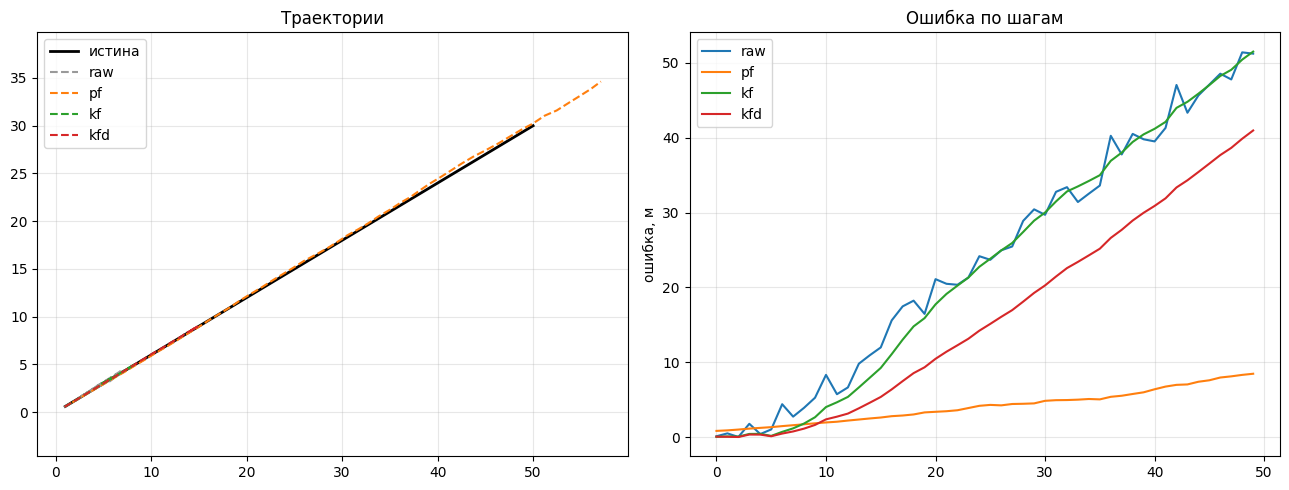

БЛОК E: CRLB σ_TDOA - зависимость от полосы источника
  SNR=10 дБ, T=0.1 с; σ_τ ухудшается на узкой полосе (drone/bird):
    источник  B_eff      gcc    srp  music   (поперечная 300м, 8mic, compact, м)
   broadband   2000Гц   7.25   3.26   3.03
       drone    300Гц  32.08  12.83   5.35
         car   4000Гц   5.47   2.46   2.66
       siren   1500Гц  12.34   4.81   2.59
        bird   6000Гц   4.62   2.50   2.68
БЛОК F: комбинированная система (звук+камера+дальность)

 Лучшая конфигурация на диаметр сферы (первичное наведение)
    env  dist  diam  ok SNR t_acq                                                 cfg
  quiet   100   1.0  да   0   0.8                     14mic/srp/compact/8K_FOV15/size
  quiet   100   2.5  да   0   0.8                     14mic/srp/compact/8K_FOV15/size
  quiet   300   1.0  да   0   0.8     14mic/srp/compact/8K_FOV15/distributed_acoustic
  quiet   300   2.5  да   0   0.8     14mic/srp/compact/8K_FOV15/distributed_acoustic
  quiet   500   1.0  да   0   0.8   

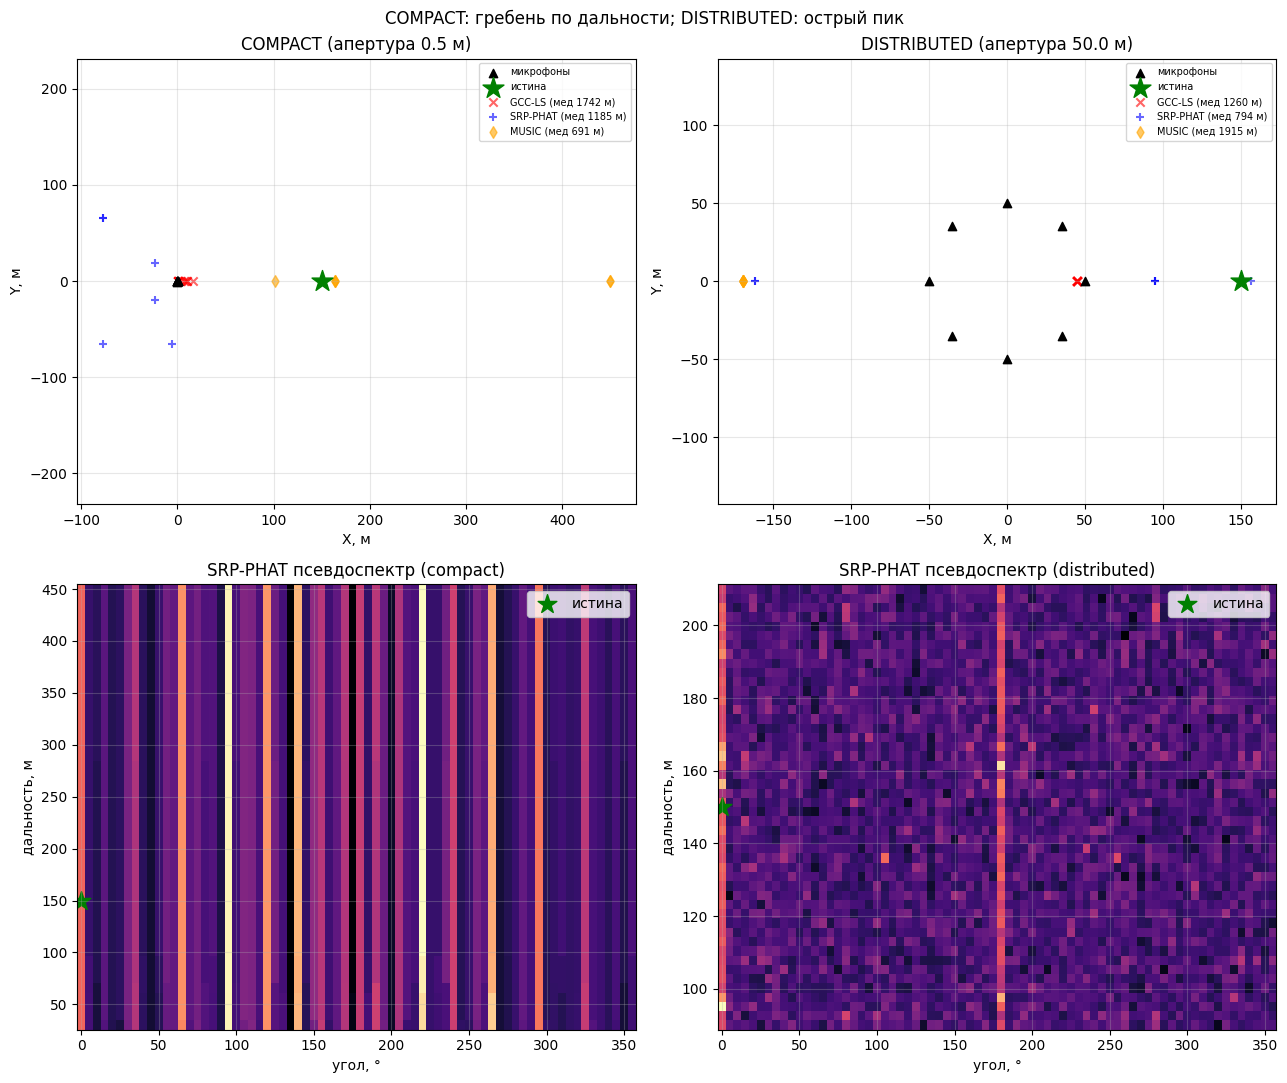

БЛОК H: мин. SNR для поперечной < X м (compact, srp, 300 м) 
 mics  ideal<5м  ideal<2м  drone<5м  drone<2м  +wind7<5м +wind7<2м  +urban_mp<5м  +urban_mp<2м
    4        10        20        25        30         20       >30            20            30
    6        10        20        20        30         20       >30            20            30
    8        10        15        20        30         15       >30            15            30
   12         5        15        20        25         15       >30            15            25
   14         5        15        20        25         15       >30            15            25
   16         5        15        20        25         15       >30            15            25
БЛОК I: ФИЗИКА НАРУЖНОЙ СРЕДЫ
  точка: compact, 8 mic, SNR=10, dist=300 м, поперечная ошибка, м

спектр источника × алгоритм (ветер=0, mp=low):
             gcc    srp  music   best
broadband   7.25   3.26   3.03  music
drone      32.08  12.83   5.35  music
car         5.47

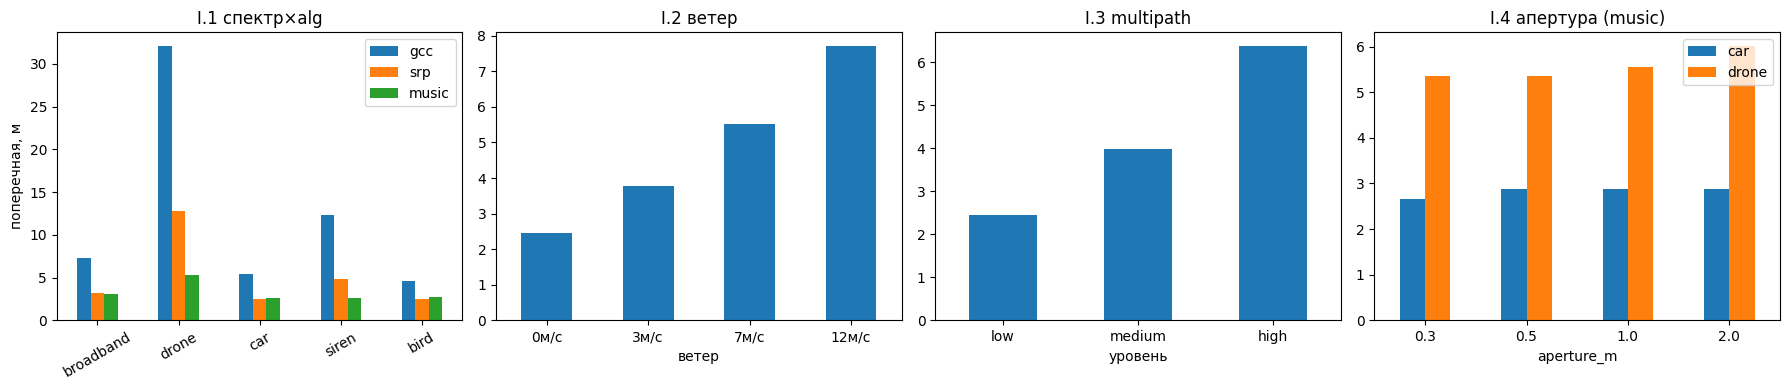

БЛОК J:

J.1 Угловая ошибка (°) и поперечная ошибка (м) — compact, 10 mic, SNR=10, dist=200 м
------------------------------------------------------------------------------------------
 Частота    λ,м    GCC°    SRP°  MUSIC°   ⊥GCC,м   ⊥SRP,м  ⊥MUSIC,м
------------------------------------------------------------------------------------------
   200 Гц   1.72    1.24    0.56    0.37     4.34     1.95      1.30
   400 Гц   0.86    0.92    0.42    0.28     3.22     1.45      0.97
   800 Гц   0.43    0.87    0.39    0.26     3.04     1.37      0.91
  1000 Гц   0.34    0.88    0.39    0.26     3.06     1.37      0.92
  1500 Гц   0.23    0.91    0.41    0.27     3.19     1.43      0.96
  2000 Гц   0.17    0.96    0.43    0.29     3.36     1.51      1.01
  3000 Гц   0.11    0.80    0.36    0.24     2.80     1.26      0.84
------------------------------------------------------------------------------------------
  σ_θ = c·σ_τ/(L·√N)·alg·alias;  ⊥ = dist·σ_θ

J.2 Поперечная ошибка (м) для MUSIC

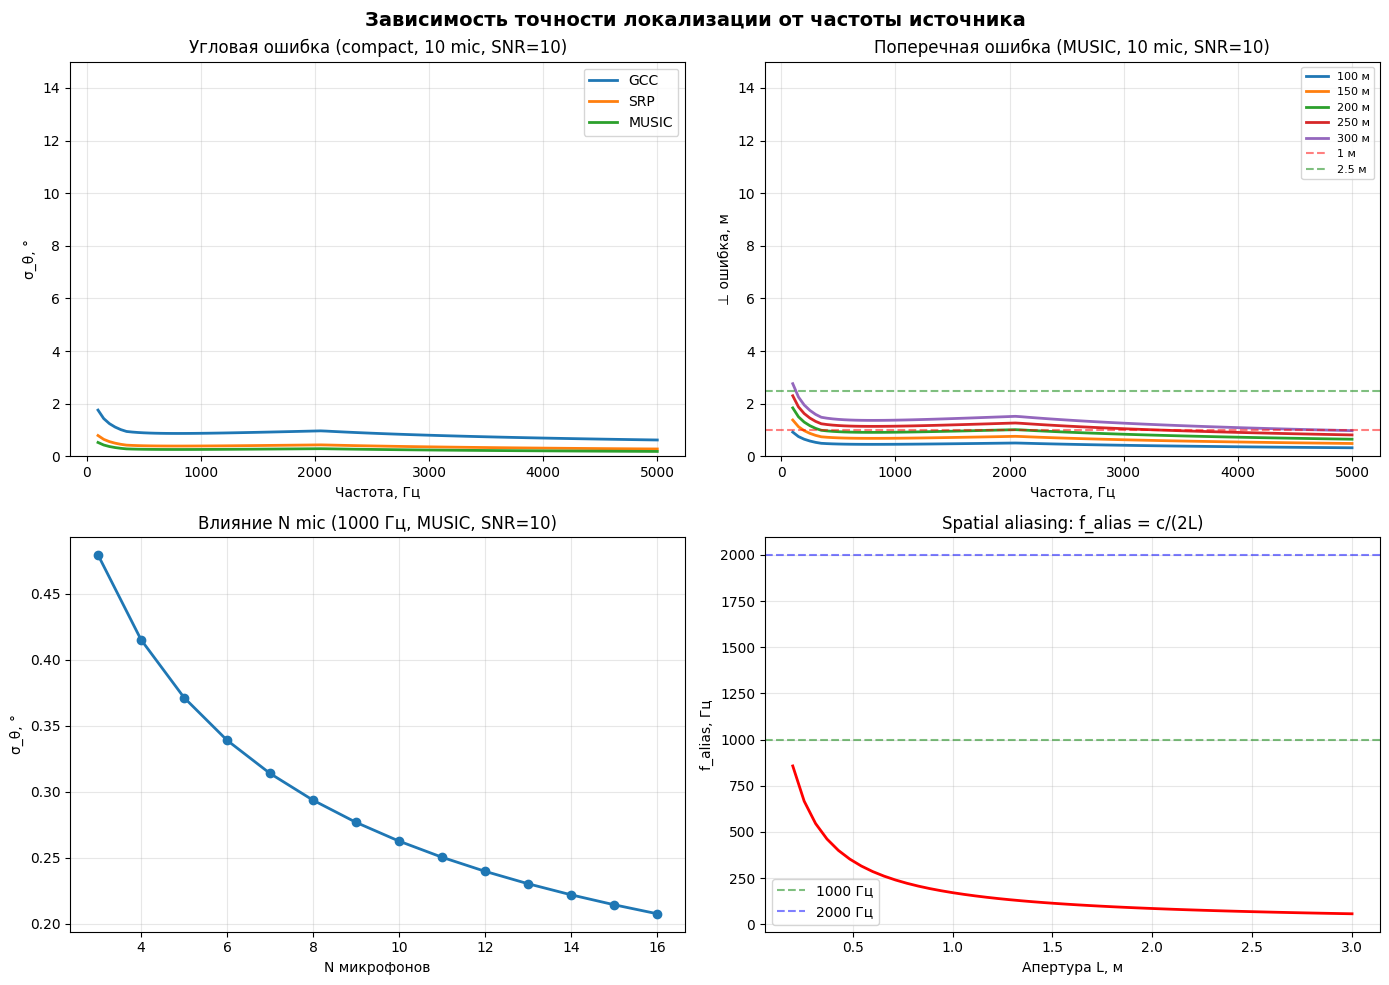

БЛОК K: Стереозрение для определения дальности

K.1 Ошибка дальности стерео (камера 1080p_FOV60, σ_disparity = 1 px)
--------------------------------------------------------------------------------
n_cams          2      3      4
dist base                      
100  1.0     5.45   3.15   2.23
     2.0     2.73   1.57   1.11
     5.0     1.09   0.63   0.45
     10.0    0.55   0.31   0.22
150  1.0    12.27   7.09   5.01
     2.0     6.14   3.54   2.50
     5.0     2.45   1.42   1.00
     10.0    1.23   0.71   0.50
200  1.0    21.82  12.60   8.91
     2.0    10.91   6.30   4.45
     5.0     4.36   2.52   1.78
     10.0    2.18   1.26   0.89
300  1.0    49.09  28.34  20.04
     2.0    24.54  14.17  10.02
     5.0     9.82   5.67   4.01
     10.0    4.91   2.83   2.00
500  1.0   136.35  78.72  55.67
     2.0    68.18  39.36  27.83
     5.0    27.27  15.74  11.13
     10.0   13.64   7.87   5.57

Замечание: ошибка растёт пропорционально квадрату расстояния, уменьшается с базой и корнем из чис

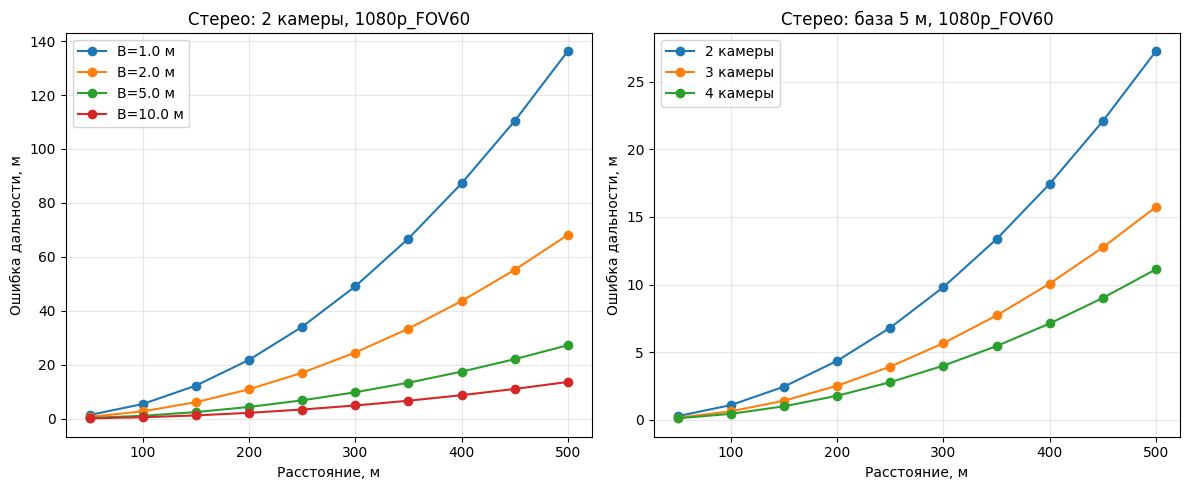


K.4 Влияние разрешения камеры на точность стерео (B=5м, 2 камеры)
--------------------------------------------------------------------------------
  1080p_FOV60: sigma_z = 4.36 м
  4K_FOV30: sigma_z = 1.09 м
  8K_FOV15: sigma_z = 0.27 м


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ---------------------------- Константы -------------------------------------
C            = 343.0
REF_MIC      = 0
SIGMA_T0     = 1e-4
B0           = 2000.0        # широкополосный референс полосы (Гц)
PAN_SPEED    = 1.047
PROC_CAPTURE = 0.30
PROC_SCAN    = 0.50
PARK_SECTOR  = np.deg2rad(120.0)
K_COV        = 3.0
REAL_OBJ_SIZE= 2.0
PX_ERR       = 2.0
SYNC_FLOOR   = 0.40
DOPPLER_RMSE = 2.0

# Параметры стереокамер
STEREO_BASES = [1.0, 2.0, 5.0, 10.0]      # метры
STEREO_NUM_CAMS = [2, 3, 4]               # количество камер
STEREO_DISPARITY_SIGMA = 1.0              # пикселей (СКО ошибки сопоставления)

SOURCE_TYPES = {
    'broadband': dict(B_eff=2000.0, best='srp',   pen={'gcc':1.0,'srp':1.0,'music':1.3}),
    'drone':     dict(B_eff=300.0,  best='music', pen={'gcc':1.8,'srp':1.6,'music':1.0}),
    'car':       dict(B_eff=4000.0, best='srp',   pen={'gcc':1.0,'srp':1.0,'music':1.4}),
    'siren':     dict(B_eff=1500.0, best='music', pen={'gcc':1.5,'srp':1.3,'music':1.0}),
    'bird':      dict(B_eff=6000.0, best='gcc',   pen={'gcc':1.0,'srp':1.2,'music':1.6}),
}

WIND_SPEEDS    = [0, 3, 7, 12]                 # м/с
MULTIPATH      = {'low':(1.0,0.0),'medium':(1.6,0.5),'high':(2.5,1.5)}  # (множит., floor м)
APERTURES      = [0.3, 0.5, 1.0, 2.0]          # м
K_WIND         = 0.5                           # усреднение cos(θ) по углам прихода

MIC_COUNTS = [3, 4, 6, 8, 10, 12, 16]
DISTANCES  = np.array([50,100,150,200,250,300,400,500], float)
SNR_DB     = np.array([-15,-10,-5,0,5,10,15,20,25,30], float)
ALGORITHMS = ['gcc','srp','music']
ALG_FACTOR = {'gcc':1.00,'srp':0.45,'music':0.30}
GEOMETRIES = ['circular','linear','random','tetrahedral']
GEO_FACTOR = {'circular':1.00,'random':1.20,'linear':1.50,'tetrahedral':0.85}
TOPOLOGIES = {'compact':dict(L_eff=0.5,gdop=3.0),
              'distributed':dict(L_eff=50.0,gdop=1.5),
              'distributed_wide':dict(L_eff=100.0,gdop=1.2)}
CAMERAS = {'1080p_FOV60':dict(W=1920,fov_deg=60.0),'4K_FOV30':dict(W=3840,fov_deg=30.0),
           '8K_FOV15':dict(W=7680,fov_deg=15.0)}
ENV = {'quiet':dict(snr_pen=0.0,rev=0.0),'urban':dict(snr_pen=12.0,rev=1.5),
       'forest':dict(snr_pen=8.0,rev=2.5),'highway':dict(snr_pen=18.0,rev=0.5)}
np.random.seed(42); RNG = np.random.default_rng(42)

def build_array(n_mics, geometry='circular', radius=0.5, seed=0):
    r = np.random.default_rng(seed)
    if geometry=='circular':
        a=np.linspace(0,2*np.pi,n_mics,endpoint=False); return np.column_stack([radius*np.cos(a),radius*np.sin(a)])
    if geometry=='linear':
        x=np.linspace(-radius,radius,n_mics); return np.column_stack([x,np.zeros(n_mics)])
    if geometry=='random':
        a=r.uniform(0,2*np.pi,n_mics); rr=radius*np.sqrt(r.uniform(.3,1.,n_mics)); return np.column_stack([rr*np.cos(a),rr*np.sin(a)])
    if geometry=='tetrahedral':
        base=np.array([[1,0,-1],[-1,0,-1],[0,1,-1],[0,-1,-1]],float); apex=np.array([[0,0,1.2]])
        pts=np.vstack([base,apex])[:n_mics]
        if n_mics>5:
            a=np.linspace(0,2*np.pi,n_mics-5,endpoint=False)
            pts=np.vstack([pts,np.column_stack([np.cos(a),np.sin(a),-np.ones(n_mics-5)])])
        return pts*radius
    raise ValueError(geometry)

def eff_aperture(mic):
    d=[np.linalg.norm(mic[i]-mic[j]) for i,j in combinations(range(len(mic)),2)]
    return float(np.mean(d)) if d else 0.0

# Физика угловой ошибки
def sigma_tdoa(snr_db, B_eff=B0):
    """СКО TDOA: базовое * (B0/B_eff)^0.5  (из CRLB: σ_τ ухудшается на узкой полосе)."""
    base = SIGMA_T0/np.sqrt(max(10**(snr_db/10),1e-3))
    return base*np.sqrt(B0/max(B_eff,1.0))**1.0     # показатель 1.0 — мягкая зависимость

def ang_err_rad(snr_db,n_mics,L_eff,gdop,alg='gcc',geo='circular',B_eff=B0):
    f=ALG_FACTOR[alg]*GEO_FACTOR[geo]
    return (C*sigma_tdoa(snr_db,B_eff))/(L_eff*np.sqrt(n_mics))*gdop*f

def trans_err_m(snr_db,dist,n_mics,topo='compact',alg='gcc',geo='circular',B_eff=B0):
    L,g=TOPOLOGIES[topo]['L_eff'],TOPOLOGIES[topo]['gdop']
    return dist*ang_err_rad(snr_db,n_mics,L,g,alg,geo,B_eff)

# полная поперечная ошибка с физикой среды
def env_trans_err(snr_db,dist,n_mics,topo='compact',alg='gcc',geo='circular',
                  source='broadband',wind=0.0,multipath='low',aperture=None):
    st=SOURCE_TYPES[source]; B_eff=st['B_eff']
    base=trans_err_m(snr_db,dist,n_mics,topo,alg,geo,B_eff)
    spec=st['pen'][alg]                                   # спектр × алгоритм
    mp_f,mp_floor=MULTIPATH[multipath]                    
    base_env=np.sqrt((base*spec*mp_f)**2 + mp_floor**2)
    wind_err=dist*(wind/C)*K_WIND                         # ветер: Δc/c · dist

    if aperture is None: aperture=TOPOLOGIES[topo]['L_eff']*0.6
    f_hi=st['B_eff']; lam_min=C/max(f_hi,1.0)
    ali=max(0.0, aperture/(lam_min/2.0) - 1.0)
    ali_k=0.02 if alg!='music' else 0.05
    ali_factor=1.0+ali_k*min(ali,8.0)
    return base_env*ali_factor + wind_err                 # м (поперечная)

# TDOA + LS + SRP/MUSIC
def _pos(src):
    s=np.asarray(src,float).ravel(); return s[:2] if s.shape[0]==4 else s
def _src3(src,mic):
    s=_pos(src); return np.concatenate([s,[0.0]]) if (mic.shape[1]==3 and s.shape[0]==2) else s
def tdoa_true(src,mic):
    t=np.linalg.norm(mic-_src3(src,mic),axis=1)/C; return t-t[REF_MIC]
def ls_position(mic,meas):
    r=least_squares(lambda p: tdoa_true(p,mic)-meas,[0.,0.],method='trf',max_nfev=200); return r.x,r.success
def _gen_wideband(src,mic,fs=8000,B=2000,T=0.05,snr_db=10):
    N=int(fs*T); ff=np.fft.rfftfreq(N,1/fs); S=np.fft.rfft(np.random.randn(N)); S[ff>B]=0; s=np.fft.irfft(S,N)
    sig=np.var(s); M=mic.shape[0]; X=np.zeros((M,len(ff)),complex); tau=tdoa_true(src,mic)
    for m in range(M):
        xm=np.fft.irfft(S*np.exp(-1j*2*np.pi*ff*tau[m]),N); n=np.random.randn(N)*np.sqrt(sig/max(10**(snr_db/10),1e-3))
        X[m]=np.fft.rfft(xm+n)
    return X,ff,fs
def _gen_narrowband(src,mic,f0=1000,fs=8000,K=256,snr_db=10):
    M=mic.shape[0]; t=np.arange(K)/fs; s=np.exp(1j*2*np.pi*f0*t); X=np.zeros((M,K),complex); tau=tdoa_true(src,mic)
    npow=0.5/max(10**(snr_db/10),1e-3)
    for m in range(M):
        n=(RNG.standard_normal(K)+1j*RNG.standard_normal(K))*np.sqrt(npow); X[m]=s*np.exp(-1j*2*np.pi*f0*tau[m])+n
    return X,f0
def srp_phat_position(src_true,mic,snr_db,n_ang=72,r_rng=(0.2,3.0)):
    X,ff,fs=_gen_wideband(src_true,mic,snr_db=snr_db); M=mic.shape[0]; pairs=list(combinations(range(M),2)); gcc=[]
    for i,j in pairs:
        G=X[i]*X[j].conj(); G/=(np.abs(G)+1e-12); gcc.append(np.fft.ifft(G).real)
    d=np.linalg.norm(src_true); angs=np.linspace(0,2*np.pi,n_ang,endpoint=False); rngs=np.linspace(r_rng[0]*d,r_rng[1]*d,48)
    srp=np.zeros((n_ang,len(rngs)))
    for ia,a in enumerate(angs):
        for ir,rr in enumerate(rngs):
            p=np.array([rr*np.cos(a),rr*np.sin(a)]); t=tdoa_true(p,mic); s=0.0
            for k,(i,j) in enumerate(pairs):
                idx=int(round((t[j]-t[i])*fs))%len(gcc[k]); s+=gcc[k][idx]
            srp[ia,ir]=s
    ia,ir=np.unravel_index(np.argmax(srp),srp.shape); return np.array([rngs[ir]*np.cos(angs[ia]),rngs[ir]*np.sin(angs[ia])]),(angs,rngs,srp)
def music_position(src_true,mic,snr_db,n_ang=72,r_rng=(0.2,3.0)):
    X,f0=_gen_narrowband(src_true,mic,snr_db=snr_db); M=mic.shape[0]; R=X@X.conj().T/X.shape[1]; w,V=np.linalg.eigh(R); En=V[:,:M-1]
    d=np.linalg.norm(src_true); angs=np.linspace(0,2*np.pi,n_ang,endpoint=False); rngs=np.linspace(r_rng[0]*d,r_rng[1]*d,48)
    P=np.zeros((n_ang,len(rngs)))
    for ia,a in enumerate(angs):
        for ir,rr in enumerate(rngs):
            p=np.array([rr*np.cos(a),rr*np.sin(a)]); t=tdoa_true(p,mic); a_vec=np.exp(-1j*2*np.pi*f0*t)
            P[ia,ir]=1.0/(np.linalg.norm(En.conj().T@a_vec)**2+1e-12)
    ia,ir=np.unravel_index(np.argmax(P),P.shape); return np.array([rngs[ir]*np.cos(angs[ia]),rngs[ir]*np.sin(angs[ia])]),(angs,rngs,P)
def monte_carlo(n_mics,dist,snr_db,geo='circular',n_ang=8,n_rep=20):
    mic=build_array(n_mics,geo); ee,er,et=[],[],[]
    for a in np.linspace(0,2*np.pi,n_ang,endpoint=False):
        src=np.array([dist*np.cos(a),dist*np.sin(a)]); u=src/np.linalg.norm(src)
        for _ in range(n_rep):
            m=tdoa_true(src,mic)+RNG.normal(0,sigma_tdoa(snr_db),mic.shape[0]); m[0]=0; est,ok=ls_position(mic,m)
            if not ok: continue
            d=est-src; rd=float(np.dot(d,u)); ee.append(np.linalg.norm(d)); er.append(abs(rd)); et.append(np.linalg.norm(d-rd*u))
    ee,er,et=map(np.asarray,(ee,er,et)); q=lambda x,p: float(np.percentile(x,p)) if len(x) else np.nan
    return dict(eu_p50=q(ee,50),eu_p90=q(ee,90),rad_p50=q(er,50),tr_p50=q(et,50),tr_p90=q(et,90))

# Камера + дальность + 3D RMSE
def cam_ang(cam): return np.deg2rad(cam['fov_deg'])/cam['W']*PX_ERR
def cam_tr(dist,cam): return dist*cam_ang(cam)
def range_err(dist,src,cam,stereo_base=None,stereo_n_cams=2):
    if src=='radar': return DOPPLER_RMSE
    if src=='distributed_acoustic':
        b=(dist/TOPOLOGIES['distributed']['L_eff'])*C*sigma_tdoa(10); return np.sqrt((b*2)**2+SYNC_FLOOR**2)
    if src=='size':
        fpx=cam['W']/np.deg2rad(cam['fov_deg']); px=max(REAL_OBJ_SIZE/dist*fpx,1.); return dist*(PX_ERR/px)
    if src=='stereo':
        if stereo_base is None:
            raise ValueError("stereo_base required for stereo source")
        return stereo_range_err(dist,cam,stereo_base,stereo_n_cams)
    return np.inf
def stereo_range_err(distance_m, cam, base_m, n_cams=2):
    """
    Ошибка дальности при стереозрении.
    distance_m - истинное расстояние до объекта, м
    cam - словарь камеры (fov_deg, W)
    base_m - база между крайними камерами, м
    n_cams - количество камер (для усреднения пар)
    """
    pixel_angle = np.deg2rad(cam['fov_deg']) / cam['W']
    n_pairs = n_cams * (n_cams - 1) / 2.0
    sigma_d_eff = STEREO_DISPARITY_SIGMA / np.sqrt(n_pairs)
    sigma_z = (distance_m**2 * pixel_angle * sigma_d_eff) / base_m
    return sigma_z
def rmse_3d(dist,snr,nm,cam,topo,alg,rsrc,env='quiet',geo='circular',stereo_base=None,stereo_n_cams=2):
    se=snr-ENV[env]['snr_pen']; tr=cam_tr(dist,cam); r=np.sqrt(range_err(dist,rsrc,cam,stereo_base,stereo_n_cams)**2+ENV[env]['rev']**2)
    return np.sqrt(2*tr**2+r**2),se
def point_time(dist,snr,nm,cam,topo,alg,scen='acq',geo='circular'):
    L,g=TOPOLOGIES[topo]['L_eff'],TOPOLOGIES[topo]['gdop']; s=ang_err_rad(snr,nm,L,g,alg,geo); hf=.5*np.deg2rad(cam['fov_deg'])
    cov=(K_COV*s)<=hf
    if scen=='track': return 0.10/PAN_SPEED+PROC_CAPTURE,cov
    turn=.25*PARK_SECTOR/PAN_SPEED
    return (turn+PROC_CAPTURE,True) if cov else (turn+2*K_COV*s/PAN_SPEED+PROC_SCAN,False)

# Байесовские фильтры
class PF:
    def __init__(s,N=2000,dt=.2,q=.2,r=5e-4): s.N,s.dt,s.q,s.r=N,dt,q,r
    def init(s,x0,P0): s.p=RNG.multivariate_normal(x0,P0,s.N); s.w=np.ones(s.N)/s.N
    def predict(s):
        F=np.array([[1,0,s.dt,0],[0,1,0,s.dt],[0,0,1,0],[0,0,0,1.]]); Q=np.eye(4)*s.q**2
        s.p=(F@s.p.T).T+RNG.multivariate_normal(np.zeros(4),Q,s.N)
    def update(s,z,mic):
        for i in range(s.N):
            d=tdoa_true(s.p[i],mic)-z; s.w[i]=np.exp(-.5*np.sum(d**2)/s.r**2)
        s.w/=s.w.sum(); idx=RNG.choice(s.N,s.N,p=s.w); s.p=s.p[idx]; s.w[:]=1./s.N
    def est(s): return np.average(s.p,axis=0,weights=s.w)
class KF:
    def __init__(s,dt=.2,q=.3,rp=3.):
        s.dt,s.q=dt,q; s.F=np.array([[1,0,dt,0],[0,1,0,dt],[0,0,1,0],[0,0,0,1.]])
        s.H=np.array([[1,0,0,0],[0,1,0,0.]]); s.Q=np.eye(4)*q**2; s.R=np.eye(2)*rp**2
    def init(s,x0,P0): s.x=np.asarray(x0,float); s.P=np.asarray(P0,float)
    def predict(s): s.x=s.F@s.x; s.P=s.F@s.P@s.F.T+s.Q
    def upos(s,z):
        y=np.asarray(z)-s.H@s.x; S=s.H@s.P@s.H.T+s.R; K=s.P@s.H.T@np.linalg.inv(S); s.x=s.x+K@y; s.P=(np.eye(4)-K@s.H)@s.P
    def udop(s,vr,los):
        H=np.array([[0,0,los[0],los[1]]]); R=np.array([[.2**2]]); y=np.array([vr])-H@s.x
        S=H@s.P@H.T+R; K=s.P@H.T@np.linalg.inv(S); s.x=s.x+(K@y).ravel(); s.P=(np.eye(4)-K@H)@s.P
    def est(s): return s.x
def track_demo(snr=10.,dt=.2,n=50,v=(5.,3.)):
    mic=build_array(6,'circular'); x=np.array([0.,0.,*v]); tr,mp,raw,dv=[],[],[],[]
    F=np.array([[1,0,dt,0],[0,1,0,dt],[0,0,1,0],[0,0,0,1.]])
    for _ in range(n):
        x=F@x; tr.append(x[:2].copy()); z=tdoa_true(x,mic)+RNG.normal(0,sigma_tdoa(snr),mic.shape[0]); z[0]=0
        p,_=ls_position(mic,z); mp.append(p); raw.append(p); los=x[:2]/max(np.linalg.norm(x[:2]),1e-6); dv.append(np.dot(x[2:],los))
    tr=np.array(tr); raw=np.array(raw)
    pf=PF(); pf.init(np.array([0,0,*v]),np.diag([1,1,.5,.5])); ep=[]
    for t in range(n):
        z=tdoa_true(tr[t],mic)+RNG.normal(0,sigma_tdoa(snr),mic.shape[0]); z[0]=0; pf.predict(); pf.update(z,mic); ep.append(pf.est()[:2])
    ep=np.array(ep)
    kf=KF(); kf.init(np.array([0,0,*v]),np.diag([5,5,1,1])); ek=[]
    for t in range(n): kf.predict(); kf.upos(mp[t]); ek.append(kf.est()[:2])
    ek=np.array(ek)
    kfd=KF(); kfd.init(np.array([0,0,*v]),np.diag([5,5,1,1])); ekd=[]
    for t in range(n):
        los=tr[t]/max(np.linalg.norm(tr[t]),1e-6); kfd.predict(); kfd.upos(mp[t]); kfd.udop(dv[t]+RNG.normal(0,.1),los); ekd.append(kfd.est()[:2])
    ekd=np.array(ekd)
    E=lambda e: np.linalg.norm(e-tr,axis=1)
    return tr,dict(raw=E(raw),pf=E(ep),kf=E(ek),kfd=E(ekd)),dict(raw=raw,pf=ep,kf=ek,kfd=ekd)
def crlb_sigma(snr,B=500.,T=.1): return np.sqrt(3./(2*np.pi**2*T*B**3*max(10**(snr/10),1e-3)))

# БЛОК A
print("БЛОК A: Monte-Carlo TDOA — вырожденность дальности (compact, SNR=10)")
rows=[]
for nm in [4,6,8,10,12]:
    for d in [100,200,300,500]:
        r=monte_carlo(nm,d,10.,'circular')
        rows.append(dict(mics=nm,dist=d,eu_p50=round(r['eu_p50'],1),eu_p90=round(r['eu_p90'],1),
                         rad_p50=round(r['rad_p50'],1),tr_p50=round(r['tr_p50'],2),tr_p90=round(r['tr_p90'],2)))
print(pd.DataFrame(rows).to_string(index=False))

# БЛОК B
print("БЛОК B: поперечная ошибка по алгоритмам/топологиям (SNR=-20, broadband)")
rows=[]
for topo in TOPOLOGIES:
    for alg in ALGORITHMS:
        for nm in [6,8,10,12]:
            for d in [100,300,500]:
                rows.append(dict(topo=topo,alg=alg,mics=nm,dist=d,tr=round(trans_err_m(-20,d,nm,topo,alg),2)))
dfb=pd.DataFrame(rows)
print(dfb.pivot_table(index=['topo','dist'],columns=['alg','mics'],values='tr').round(2).to_string()); print()

# БЛОК C
print("БЛОК C: геометрии массива (compact, SNR=10, 8 mic, поперечная 300м)")
for g in GEOMETRIES:
    mic=build_array(8,g); print(f"  {g:11s}: апертура={eff_aperture(mic):.2f} м  "
          f"поперечная={trans_err_m(10,300,8,'compact','srp',g):.1f} м  geo_factor={GEO_FACTOR[g]}"); print() if False else None

# БЛОК D
print("БЛОК D: трекинг (SNR=10) - raw / Particle / Kalman / Kalman+Doppler")
tr,errs,ests=track_demo(10.)
print(pd.DataFrame({k:[round(np.mean(v),3),round(np.median(v),3)] for k,v in errs.items()},index=['mean_m','median_m']).to_string())
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].plot(tr[:,0],tr[:,1],'k-',lw=2,label='истина')
for k,c in [('raw','0.6'),('pf','C1'),('kf','C2'),('kfd','C3')]: ax[0].plot(ests[k][:,0],ests[k][:,1],'--',c=c,label=k)
ax[0].set(title='Траектории'); ax[0].legend(); ax[0].grid(alpha=.3); ax[0].axis('equal')
for k in errs: ax[1].plot(errs[k],label=k)
ax[1].set(ylabel='ошибка, м',title='Ошибка по шагам'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# БЛОК E
print("БЛОК E: CRLB σ_TDOA - зависимость от полосы источника")
print("  SNR=10 дБ, T=0.1 с; σ_τ ухудшается на узкой полосе (drone/bird):")
hdr="  {:>10s}".format("источник")+"  B_eff  "+"".join(f"{a:>7s}" for a in ['gcc','srp','music'])+"   (поперечная 300м, 8mic, compact, м)"
print(hdr)
for sname,st in SOURCE_TYPES.items():
    row=f"  {sname:>10s}  {st['B_eff']:5.0f}Гц"
    vals=[env_trans_err(10,300,8,'compact',a,'circular',source=sname) for a in ALGORITHMS]
    row+="".join(f"{v:7.2f}" for v in vals); print(row)


# БЛОК F
print("БЛОК F: комбинированная система (звук+камера+дальность)")
rows=[]
for env in ENV:
    for d in [50,100,200,300,500]:
        for snr in [0,5,10,15,20]:
            for nm in [14,16]:
                for alg in ['srp','music']:
                    for topo in TOPOLOGIES:
                        for cn,cam in CAMERAS.items():
                            for rs in ['radar','distributed_acoustic','size']:
                                e3,se=rmse_3d(d,snr,nm,cam,topo,alg,rs,env); ta,co=point_time(d,se,nm,cam,topo,alg,'acq')
                                rows.append(dict(env=env,dist=d,SNR=snr,mics=nm,alg=alg,topo=topo,cam=cn,rs=rs,RMSE=round(e3,3),cov=int(co),t_acq=round(ta,3)))
df=pd.DataFrame(rows)
def best(diam,sub):
    ok=sub[sub['RMSE']<=diam/2.]; return None if ok.empty else ok.sort_values(['t_acq','RMSE']).iloc[0]
print("\n Лучшая конфигурация на диаметр сферы (первичное наведение)")
sr=[]
for env in ENV:
    for d in [100,300,500]:
        for diam in [1.0,2.5]:
            b=best(diam,df[(df['env']==env)&(df['dist']==d)])
            sr.append(dict(env=env,dist=d,diam=diam,ok='да' if b is not None else 'НЕТ',
                SNR=int(b['SNR']) if b is not None else '-',t_acq=b['t_acq'] if b is not None else '-',
                cfg=f"{int(b['mics'])}mic/{b['alg']}/{b['topo']}/{b['cam']}/{b['rs']}" if b is not None else '-'))
print(pd.DataFrame(sr).to_string(index=False))
print("\n Почему 'size' не работает вдали (σ_range ~ D^2)")
for d in [100,300,500]:
    di=int(round(d)); print(f"  d={di:3d}м: size={range_err(d,'size',CAMERAS['1080p_FOV60']):8.1f}м  "
          f"radar={range_err(d,'radar',CAMERAS['1080p_FOV60']):.1f}м  distr.acoust.={range_err(d,'distributed_acoustic',CAMERAS['1080p_FOV60']):.2f}м")

# БЛОК G
print("БЛОК G: ДЕМО локализации - compact vs distributed (SNR=10, 150 м)")
SRC=np.array([150.,0.]); fig,ax=plt.subplots(2,2,figsize=(13,11))
for col,topo in enumerate(['compact','distributed']):
    rad=0.5 if topo=='compact' else 50.0; mic=build_array(8,'circular',rad); ls_c,srp_c,mus_c=[],[],[]
    for _ in range(12):
        m=tdoa_true(SRC,mic)+RNG.normal(0,sigma_tdoa(10),mic.shape[0]); m[0]=0; p,_=ls_position(mic,m); ls_c.append(p)
    for _ in range(6):
        rr=(0.2,3.0) if topo=='compact' else (0.6,1.4); srp_c.append(srp_phat_position(SRC,mic,10,r_rng=rr)[0]); mus_c.append(music_position(SRC,mic,10,r_rng=rr)[0])
    ls_c,srp_c,mus_c=map(np.asarray,(ls_c,srp_c,mus_c)); a=ax[0,col]
    a.scatter(mic[:,0],mic[:,1],c='k',marker='^',label='микрофоны',zorder=5); a.scatter(*SRC,c='g',marker='*',s=250,label='истина',zorder=6)
    a.scatter(ls_c[:,0],ls_c[:,1],c='r',marker='x',alpha=.6,label=f'GCC-LS (мед {np.median(np.linalg.norm(ls_c-SRC,1)):.0f} м)')
    a.scatter(srp_c[:,0],srp_c[:,1],c='b',marker='+',alpha=.6,label=f'SRP-PHAT (мед {np.median(np.linalg.norm(srp_c-SRC,1)):.0f} м)')
    a.scatter(mus_c[:,0],mus_c[:,1],c='orange',marker='d',alpha=.6,label=f'MUSIC (мед {np.median(np.linalg.norm(mus_c-SRC,1)):.0f} м)')
    a.set(title=f'{topo.upper()} (апертура {rad} м)'); a.legend(fontsize=7); a.grid(alpha=.3); a.set(xlabel='X, м',ylabel='Y, м'); a.axis('equal')
    _,(angs,rngs,srp)=srp_phat_position(SRC,mic,10,r_rng=(0.2,3.0) if topo=='compact' else (0.6,1.4)); b=ax[1,col]
    b.pcolormesh(np.degrees(angs),rngs,srp.T,shading='nearest',cmap='magma')
    b.scatter(np.degrees(np.arctan2(SRC[1],SRC[0]))%360,np.linalg.norm(SRC),c='g',marker='*',s=200,label='истина')
    b.set(title=f'SRP-PHAT псевдоспектр ({topo})',xlabel='угол, °',ylabel='дальность, м'); b.legend(); b.grid(alpha=.3)
plt.suptitle('COMPACT: гребень по дальности; DISTRIBUTED: острый пик'); plt.tight_layout(); plt.show()

# БЛОК H
print("БЛОК H: мин. SNR для поперечной < X м (compact, srp, 300 м) ")
rows=[]
for nm in [4,6,8,12,14,16]:
    row=dict(mics=nm)
    for (lbl,src,wnd,mp) in [('ideal','broadband',0,'low'),('drone','drone',0,'low'),
                             ('+wind7','broadband',7,'low'),('+urban_mp','broadband',0,'high')]:
        for thr in [5,2]:
            ok=[s for s in SNR_DB if env_trans_err(s,300,nm,'compact','srp','circular',src,wnd,mp)<=thr]
            row[f"{lbl}<{thr}м"]=int(min(ok)) if ok else '>30'
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

# БЛОК I 
print("БЛОК I: ФИЗИКА НАРУЖНОЙ СРЕДЫ")
print("  точка: compact, 8 mic, SNR=10, dist=300 м, поперечная ошибка, м")
# спектр × алгоритм
print("\nспектр источника × алгоритм (ветер=0, mp=low):")
m1=pd.DataFrame({a:[round(env_trans_err(10,300,8,'compact',a,'circular',source=s),2) for s in SOURCE_TYPES]
                 for a in ALGORITHMS}, index=list(SOURCE_TYPES))
m1['best']=m1.idxmin(axis=1); print(m1.to_string())
# ветер
print("\n ветер (источник=car, srp, mp=low):")
m2 = pd.DataFrame(
    {f"{w}м/с": [round(env_trans_err(10, 300, 8, 'compact', 'srp', 'circular', 'car', w, 'low'), 2)]
     for w in WIND_SPEEDS},
    index=['поперечная']
).T
m2.index.name = 'ветер'
print(m2.to_string())
# multipath
print("\n[I.3] MULTIPATH (источник=car, srp, ветер=0):")
m3=pd.DataFrame({mp:round(env_trans_err(10,300,8,'compact','srp','circular','car',0,mp),2) for mp in MULTIPATH}, index=['поперечная']).T
m3.index.name='уровень'; print(m3.to_string())
# апертура + aliasing
print("\n апертура + spatial aliasing (источник=car vs drone, music, mp=low):")
rows=[]
for ap in APERTURES:
    rows.append(dict(aperture_m=ap,
        car=round(env_trans_err(10,300,8,'compact','music','circular','car',0,'low',aperture=ap),2),
        drone=round(env_trans_err(10,300,8,'compact','music','circular','drone',0,'low',aperture=ap),2)))
print(pd.DataFrame(rows).to_string(index=False))

fig,ax=plt.subplots(1,4,figsize=(18,4))
m1.drop(columns='best').plot(kind='bar',ax=ax[0]); ax[0].set_title('I.1 спектр×alg'); ax[0].set_ylabel('поперечная, м'); ax[0].tick_params(axis='x',rotation=30)
m2.plot(kind='bar',ax=ax[1],legend=False); ax[1].set_title('I.2 ветер'); ax[1].tick_params(axis='x',rotation=0)
m3.plot(kind='bar',ax=ax[2],legend=False); ax[2].set_title('I.3 multipath'); ax[2].tick_params(axis='x',rotation=0)
pd.DataFrame(rows).set_index('aperture_m')[['car','drone']].plot(kind='bar',ax=ax[3]); ax[3].set_title('I.4 апертура (music)'); ax[3].tick_params(axis='x',rotation=0)
plt.tight_layout(); plt.show()


# БЛОК J
print("БЛОК J:")

FREQUENCIES = [200, 400, 800, 1000, 1500, 2000, 3000]

def angular_error_from_frequency(freq_hz, n_mics, L_eff, snr_db, algorithm='gcc'):

    snr_lin = max(10**(snr_db / 10), 1e-3)

    # CRLB: σ_τ ухудшается на узкой полосе (∝ 1/√f для узкополосного)
    sigma_tau = SIGMA_T0 / np.sqrt(snr_lin) * np.sqrt(B0 / max(freq_hz, 1.0))

    # Угловая ошибка: σ_θ = c·σ_τ / (L·√N)
    sigma_theta_base = C * sigma_tau / (L_eff * np.sqrt(n_mics))

    # Штраф алгоритма
    alg_factor = ALG_FACTOR[algorithm]

    # Spatial aliasing: f_alias = c / (2·d), d ≈ L_eff для compact
    aliasing_freq = C / (2.0 * L_eff)
    aliasing_penalty = 1.0
    if freq_hz > aliasing_freq:
        aliasing_penalty = 1.0 + 0.3 * min(freq_hz / aliasing_freq - 1.0, 5.0)

    return sigma_theta_base * alg_factor * aliasing_penalty


# J.1
print("\nJ.1 Угловая ошибка (°) и поперечная ошибка (м) — compact, 10 mic, SNR=10, dist=200 м")
print("-" * 90)
print(f"{'Частота':>8} {'λ,м':>6} {'GCC°':>7} {'SRP°':>7} {'MUSIC°':>7}"
      f" {'⊥GCC,м':>8} {'⊥SRP,м':>8} {'⊥MUSIC,м':>9}")
print("-" * 90)

DIST_J = 200.0
N_J = 10
L_J = 0.5

for freq in FREQUENCIES:
    wl = C / freq
    eg = angular_error_from_frequency(freq, N_J, L_J, 10, 'gcc')
    es = angular_error_from_frequency(freq, N_J, L_J, 10, 'srp')
    em = angular_error_from_frequency(freq, N_J, L_J, 10, 'music')
    # Поперечная = dist · σ_θ
    tg = DIST_J * eg
    ts = DIST_J * es
    tm = DIST_J * em
    print(f"{freq:>6} Гц {wl:>6.2f} {np.degrees(eg):>7.2f} {np.degrees(es):>7.2f}"
          f" {np.degrees(em):>7.2f} {tg:>8.2f} {ts:>8.2f} {tm:>9.2f}")

print("-" * 90)
print("  σ_θ = c·σ_τ/(L·√N)·alg·alias;  ⊥ = dist·σ_θ")

# J.2
print("\nJ.2 Поперечная ошибка (м) для MUSIC, 10 mic, compact, SNR=10")
print("-" * 70)
print(f"{'Частота':>8} {'100м':>8} {'150м':>8} {'200м':>8} {'250м':>8} {'300м':>8}")
print("-" * 70)

for freq in FREQUENCIES:
    em = angular_error_from_frequency(freq, N_J, L_J, 10, 'music')
    vals = [d * em for d in [100, 150, 200, 250, 300]]
    print(f"{freq:>6} Гц " + " ".join(f"{v:>8.2f}" for v in vals))

print("-" * 70)

# J.3 
print("\nJ.3 Влияние количества микрофонов (MUSIC, 1000 Гц, 200 м, SNR=10)")
print("-" * 65)
print(f"{'N mic':>6} {'σ_θ,°':>8} {'⊥,м':>8} {'улучшение':>10}")
print("-" * 65)

ref_err = angular_error_from_frequency(1000, 6, L_J, 10, 'music')
for nm in [3, 4, 6, 8, 10, 12, 16]:
    e = angular_error_from_frequency(1000, nm, L_J, 10, 'music')
    tr = DIST_J * e
    imp = 100.0 * e / ref_err
    print(f"{nm:>6} {np.degrees(e):>8.2f} {tr:>8.2f} {imp:>9.1f}%")

print("-" * 65)

# J.4 
print("\nJ.4 Влияние SNR (MUSIC, 1000 Гц, 200 м, 6 mic)")
print("-" * 65)
print(f"{'SNR,дБ':>8} {'σ_θ,°':>8} {'⊥,м':>8} {'улучшение':>10}")
print("-" * 65)

ref10 = angular_error_from_frequency(1000, N_J, L_J, 10, 'music')
for snr in [-10, -5, 0, 5, 10, 15, 20]:
    e = angular_error_from_frequency(1000, N_J, L_J, snr, 'music')
    tr = DIST_J * e
    imp = 100.0 * e / ref10
    print(f"{snr:>7} дБ {np.degrees(e):>8.2f} {tr:>8.2f} {imp:>9.1f}%")

print("-" * 65)

# J.5 
print("\nJ.5 Spatial aliasing threshold: f_alias = c/(2·L)")
print("-" * 60)
for L in [0.3, 0.5, 1.0, 2.0]:
    fa = C / (2.0 * L)
    print(f"  L={L:.1f} м → f_alias = {fa:.0f} Гц  (λ_alias = {C/fa:.2f} м)")
print("-" * 60)


# J.6
print("\nJ.6 Рекомендации по алгоритмам для разных источников")
print("-" * 85)
print(f"{'Источник':>12} {'Полоса':>22} {'Лучший alg':>12} {'Почему':>30}")
print("-" * 85)
for name, st in SOURCE_TYPES.items():
    why = {'gcc':'широкополосный, простая корреляция',
           'srp':'широкополосный, робастный к шуму',
           'music':'узкополосный/тональный, супер-разрешение'}[st['best']]
    print(f"{name:>12} {st['B_eff']:>6.0f} Гц {'':>14} {st['best']:>12} {why:>30}")
print("-" * 85)

# J.7 
print("\n[J.7] Мин. частота для поперечной < X м (MUSIC, compact L=0.5, 6 mic, SNR=10)")
print("-" * 60)
print(f"{'Дистанция':>10} {'<1м':>10} {'<2.5м':>10} {'<5м':>10}")
print("-" * 60)

for dist in [100, 150, 200, 250, 300]:
    row = [f"{dist} м"]
    for thr in [1.0, 2.5, 5.0]:
        min_f = None
        for f in range(100, 8001, 25):
            e = angular_error_from_frequency(f, N_J, L_J, 10, 'music')
            if dist * e < thr:
                min_f = f
                break
        row.append(f"{min_f} Гц" if min_f else ">8000 Гц")
    print(f"{row[0]:>10} {row[1]:>10} {row[2]:>10} {row[3]:>10}")

print("-" * 60)


# J.8
print("\nJ.8 Графики")
print("-" * 78)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Зависимость точности локализации от частоты источника',
             fontsize=14, fontweight='bold')

freqs = np.arange(100, 5001, 50)

# 1: σ_θ vs f
ax = axes[0, 0]
for alg in ['gcc', 'srp', 'music']:
    errs = [np.degrees(angular_error_from_frequency(f, N_J, L_J, 10, alg)) for f in freqs]
    ax.plot(freqs, errs, '-', lw=2, label=alg.upper())
ax.set(xlabel='Частота, Гц', ylabel='σ_θ, °',
       title=f'Угловая ошибка (compact, {N_J} mic, SNR=10)')
ax.legend(); ax.grid(alpha=.3); ax.set_ylim(0, 15)

# 2: ⊥ vs f для разных дистанций (MUSIC)
ax = axes[0, 1]
for d in [100, 150, 200, 250, 300]:
    errs = [d * angular_error_from_frequency(f, N_J, L_J, 10, 'music') for f in freqs]
    ax.plot(freqs, errs, '-', lw=2, label=f'{d} м')
ax.axhline(1.0, c='r', ls='--', alpha=.5, label='1 м')
ax.axhline(2.5, c='g', ls='--', alpha=.5, label='2.5 м')
ax.set(xlabel='Частота, Гц', ylabel='⊥ ошибка, м',
       title=f'Поперечная ошибка (MUSIC, {N_J} mic, SNR=10)')
ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_ylim(0, 15)

# 3: σ_θ vs N mic
ax = axes[1, 0]
nms = np.arange(3, 17)
errs = [np.degrees(angular_error_from_frequency(1000, n, L_J, 10, 'music')) for n in nms]
ax.plot(nms, errs, 'o-', lw=2, c='C0')
ax.set(xlabel='N микрофонов', ylabel='σ_θ, °',
       title='Влияние N mic (1000 Гц, MUSIC, SNR=10)')
ax.grid(alpha=.3)

# 4: f_alias vs апертура
ax = axes[1, 1]
aps = np.linspace(0.2, 3.0, 50)
fa = C / (2.0 * aps)
ax.plot(aps, fa, '-', lw=2, c='r')
ax.axhline(1000, c='g', ls='--', alpha=.5, label='1000 Гц')
ax.axhline(2000, c='b', ls='--', alpha=.5, label='2000 Гц')
ax.set(xlabel='Апертура L, м', ylabel='f_alias, Гц',
       title='Spatial aliasing: f_alias = c/(2L)')
ax.legend(); ax.grid(alpha=.3)

plt.tight_layout()
plt.savefig('frequency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


# БЛОК K: СТЕРЕОКАМЕРЫ
print("БЛОК K: Стереозрение для определения дальности")


# K.1: Ошибка дальности в зависимости от базы и числа камер
print("\nK.1 Ошибка дальности стерео (камера 1080p_FOV60, σ_disparity = 1 px)")
print("-"*80)
rows_k = []
for dist in [100, 150, 200, 300, 500]:
    for base in STEREO_BASES:
        for nc in STEREO_NUM_CAMS:
            err = stereo_range_err(dist, CAMERAS['1080p_FOV60'], base, nc)
            rows_k.append(dict(dist=dist, base=base, n_cams=nc, sigma_z_m=round(err,2)))
dfk = pd.DataFrame(rows_k)
print(dfk.pivot_table(index=['dist','base'], columns='n_cams', values='sigma_z_m').round(2).to_string())
print("\nЗамечание: ошибка растёт пропорционально квадрату расстояния, уменьшается с базой и корнем из числа пар камер.")

# K.2: Сравнение с другими источниками дальности
print("\nK.2 Сравнение ошибок дальности для разных источников (на 200 м)")
print("-"*80)
cam = CAMERAS['1080p_FOV60']
comp_rows = []
for src in ['radar', 'distributed_acoustic', 'size', 'stereo (B=5м, 2кам)', 'stereo (B=5м, 4кам)']:
    if src.startswith('stereo'):
        base = 5.0
        nc = 2 if '2кам' in src else 4
        err = stereo_range_err(200, cam, base, nc)
    else:
        err = range_err(200, src, cam)
    comp_rows.append(dict(source=src, sigma_range_m=round(err,2)))
print(pd.DataFrame(comp_rows).to_string(index=False))

# K.3: Графики зависимости ошибки дальности от расстояния
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for base in STEREO_BASES:
    errs = [stereo_range_err(d, CAMERAS['1080p_FOV60'], base, 2) for d in np.arange(50,501,50)]
    plt.plot(np.arange(50,501,50), errs, '-o', label=f'B={base} м')
plt.xlabel('Расстояние, м'); plt.ylabel('Ошибка дальности, м')
plt.title('Стерео: 2 камеры, 1080p_FOV60')
plt.legend(); plt.grid(alpha=.3)

plt.subplot(1,2,2)
for nc in STEREO_NUM_CAMS:
    errs = [stereo_range_err(d, CAMERAS['1080p_FOV60'], 5.0, nc) for d in np.arange(50,501,50)]
    plt.plot(np.arange(50,501,50), errs, '-o', label=f'{nc} камеры')
plt.xlabel('Расстояние, м'); plt.ylabel('Ошибка дальности, м')
plt.title('Стерео: база 5 м, 1080p_FOV60')
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig('stereo_range_error.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nK.4 Влияние разрешения камеры на точность стерео (B=5м, 2 камеры)")
print("-"*80)
for cam_name in CAMERAS:
    cam = CAMERAS[cam_name]
    err = stereo_range_err(200, cam, 5.0, 2)
    print(f"  {cam_name}: sigma_z = {err:.2f} м")


In [ ]:
import numpy as np
import pandas as pd

# Базовые константы
C        = 343.0
SIGMA_T0 = 1e-4
B0       = 2000.0
PX_ERR   = 1.0
STEREO_DISPARITY_SIGMA = 1.0
K_WIND   = 0.5
K_COV    = 3.0
T_INT    = 1.0

AIM_MOUNT_ERR_DEG = 0.1

# Источники звука
SOURCE_TYPES = {
    'car':   {'B_eff': 4000.0, 'alg': 'srp',
              'pen': {'gcc': 1.0, 'srp': 1.0, 'music': 1.4}},
    'drone': {'B_eff': 300.0,  'alg': 'music',
              'pen': {'gcc': 1.8, 'srp': 1.6, 'music': 1.0}},
}

# Алгоритмы и геометрии
ALG_FACTOR = {'gcc': 1.00, 'srp': 0.45, 'music': 0.30}
GEO_FACTOR = {'circular': 1.00, 'random': 1.20, 'linear': 1.50, 'tetrahedral': 0.85}

# Топологии (ДАЛЬНЯЯ геометрия: L_eff и gdop)
TOPOLOGIES = {
    'compact':          dict(L_eff=0.5,   gdop=3.0),
    'distributed':      dict(L_eff=50.0,  gdop=1.5),
    'distributed_wide': dict(L_eff=100.0, gdop=1.2),
}


# ЛОКАЛЬНЫЕ БАЗЫ микрофонов (aperture) — зависят от источника
APERTURES = {
    'drone': [0.3, 0.5, 1.0],
    'car':   [0.5, 1.0, 2.0, 5.0],
}

# Камеры
CAMERAS = {
    '1080p_FOV60': dict(fov_deg=60.0, W=1920, pix_err=2.0),
    '4K_FOV30':    dict(fov_deg=30.0, W=3840, pix_err=1.5),
    '8K_FOV15':    dict(fov_deg=15.0, W=7680, pix_err=1.0),
}

# Модель среды
MULTIPATH = {'low': (1.0, 0.0), 'medium': (1.6, 0.5), 'high': (2.5, 1.5)}

# Базовые функции
def sigma_tdoa(snr_db, B_eff=B0):
    base = SIGMA_T0 / np.sqrt(max(10**(snr_db / 10), 1e-3))
    return base * np.sqrt(B0 / max(B_eff, 1.0))

def ang_err_rad(snr_db, n_mics, L_eff, gdop, alg='gcc', geo='circular', B_eff=B0):
    f = ALG_FACTOR[alg] * GEO_FACTOR[geo]
    return (C * sigma_tdoa(snr_db, B_eff)) / (L_eff * np.sqrt(n_mics)) * gdop * f

def trans_err_m(snr_db, dist, n_mics, topo='compact', alg='gcc', geo='circular', B_eff=B0):
    L, g = TOPOLOGIES[topo]['L_eff'], TOPOLOGIES[topo]['gdop']
    return dist * ang_err_rad(snr_db, n_mics, L, g, alg, geo, B_eff)

def env_trans_err(snr_db, dist, n_mics, topo='compact', alg='gcc', geo='circular',
                  source='car', wind=0.0, multipath='low', aperture=None):
    st = SOURCE_TYPES[source]
    B_eff = st['B_eff']
    base = trans_err_m(snr_db, dist, n_mics, topo, alg, geo, B_eff)
    spec = st['pen'][alg]
    mp_f, mp_floor = MULTIPATH[multipath]
    base_env = np.sqrt((base * spec * mp_f)**2 + mp_floor**2)
    wind_err = dist * (wind / C) * K_WIND

    if aperture is None:
        aperture = TOPOLOGIES[topo]['L_eff'] * 0.6
    lam_min = C / max(B_eff, 1.0)
    ali = max(0.0, aperture / (lam_min / 2.0) - 1.0)
    ali_k = 0.02 if alg != 'music' else 0.05
    ali_factor = 1.0 + ali_k * min(ali, 8.0)

    return base_env * ali_factor + wind_err

# Камера и стерео
def cam_tr(dist, cam):
    pixel_ang = np.deg2rad(cam['fov_deg']) / cam['W'] * cam['pix_err']
    return dist * pixel_ang

def stereo_range_err(dist, cam, base_m, n_cams=2):
    pixel_angle = np.deg2rad(cam['fov_deg']) / cam['W']
    n_pairs = n_cams * (n_cams - 1) / 2.0
    sigma_d_eff = STEREO_DISPARITY_SIGMA / np.sqrt(n_pairs)
    return (dist**2 * pixel_angle * sigma_d_eff) / max(base_m, 0.1)

# Определение сред
L_ENV = {
    'field':   dict(mp='low',    wind=3, rev=0.0, tol=2.0,
                    snr={'car': [15, 5, -5],           'drone': [10, 0, -10]}),
    'forest':  dict(mp='medium', wind=4, rev=2.5, tol=3.0,
                    snr={'car': [5, -5, -15, -25],     'drone': [0, -10, -20, -30]}),
    'urban':   dict(mp='high',   wind=5, rev=1.5, tol=2.5,
                    snr={'car': [-10, -20, -30, -40],  'drone': [-20, -30, -40, -50]}),
    'highway': dict(mp='low',    wind=5, rev=0.5, tol=2.5,
                    snr={'car': [-15, -25, -35, -45],  'drone': [-25, -35, -45]}),
}

DISTS_L = [100, 150, 200]
MICS_L  = [8, 12, 16, 24, 32]
TOPOS_L = ['compact', 'distributed', 'distributed_wide']
CAMS_L  = ['1080p_FOV60', '4K_FOV30', '8K_FOV15']
BASES_L = [5, 10]
NCAMS_L = [2, 4]


# Spatial aliasing: порог для каждой локальной базы
print("=== SPATIAL ALIASING: f_alias = c/(2·aperture) ===")
print("Для дрона (300 Гц) λ/2 = 0.57 м — нужна база около этого значения")
print("Для машины (4 кГц) λ/2 = 0.043 м — aliasing почти всегда, но штраф мал")
print("-" * 70)
ali_rows = []
for src in ['drone', 'car']:
    B_eff = SOURCE_TYPES[src]['B_eff']
    lam_half = C / (2 * B_eff)
    for ap in APERTURES[src]:
        f_alias = C / (2 * ap)
        status = 'OK (aperture < λ/2)' if ap < lam_half else 'aliasing'
        ali_rows.append(dict(src=src, aperture_m=ap, lam_half_m=round(lam_half, 3),
                             f_alias_Hz=round(f_alias, 0), status=status))
print(pd.DataFrame(ali_rows).to_string(index=False))


# Полный перебор конфигураций
mount_err_rad = np.deg2rad(AIM_MOUNT_ERR_DEG)   # ошибка привода пан-тилт, рад

all_configs = []
for env, ea in L_ENV.items():
    for src in ['car', 'drone']:
        alg   = SOURCE_TYPES[src]['alg']
        B_eff = SOURCE_TYPES[src]['B_eff']
        for dist in DISTS_L:
            for snr in ea['snr'][src]:
                for nm in MICS_L:
                    for topo in TOPOS_L:
                        for aperture in APERTURES[src]:
                            tr_ac = env_trans_err(snr, dist, nm, topo, alg, 'circular',
                                                  source=src, wind=ea['wind'],
                                                  multipath=ea['mp'], aperture=aperture)

                            s_ang   = tr_ac / dist                 # угловая ошибка, рад
                            ang_deg = np.degrees(s_ang)            # угловая ошибка, градусы

                            # Суммарная угловая ошибка наведения = акустика + привод пан-тилт
                            aim_ang = np.sqrt(s_ang**2 + mount_err_rad**2)
                            aim_m   = dist * aim_ang               # ошибка наведения на дальности, м

                            for cam_n in CAMS_L:
                                cam = CAMERAS[cam_n]
                                if K_COV * s_ang > 0.5 * np.deg2rad(cam['fov_deg']):
                                    continue
                                tr_cam = cam_tr(dist, cam)

                                for base in BASES_L:
                                    for nc in NCAMS_L:
                                        rng = stereo_range_err(dist, cam, base, nc)
                                        tot = np.sqrt(2 * tr_cam**2 + rng**2 + ea['rev']**2)

                                        all_configs.append({
                                            'env': env, 'src': src, 'dist': dist, 'SNR': snr,
                                            'tol': ea['tol'], 'nm': nm, 'topo': topo,
                                            'aperture': aperture,
                                            'cam': cam_n, 'base': base, 'nc': nc,
                                            'ang_deg': round(ang_deg, 3),   
                                            'aim_m':   round(aim_m, 2),     
                                            'ac_m':  round(tr_ac, 2),
                                            'cam_m': round(tr_cam, 3),
                                            'rng_m': round(rng, 3),
                                            'rev_m': ea['rev'],
                                            'fin_m': round(tot, 2),
                                        })


# Вывод
df_all = pd.DataFrame(all_configs)
pd.set_option('display.width', 260)

print("\n=== ЛУЧШИЕ КОНФИГУРАЦИИ (минимальная ошибка fin_m) ===")
best = (df_all
        .groupby(['env', 'src', 'dist', 'SNR'], as_index=False)
        .apply(lambda g: g.loc[g['fin_m'].idxmin()])
        .reset_index(drop=True))
print(best[['env', 'src', 'dist', 'SNR', 'tol',
            'nm', 'topo', 'aperture', 'cam', 'base', 'nc',
            'ang_deg', 'aim_m', 'ac_m', 'fin_m']].to_string(index=False))

# Пример: все конфигурации для выбранного сценария
sel_env, sel_src, sel_dist, sel_snr = 'urban', 'drone', 150, -30
print(f"\n=== ВСЕ КОНФИГУРАЦИИ: {sel_env} / {sel_src} / {sel_dist} м / SNR={sel_snr} дБ ===")
sc = df_all[(df_all['env'] == sel_env) & (df_all['src'] == sel_src) &
            (df_all['dist'] == sel_dist) & (df_all['SNR'] == sel_snr)]
sc = sc.sort_values('fin_m')
print(sc[['nm', 'topo', 'aperture', 'cam', 'base', 'nc',
          'ang_deg', 'aim_m', 'ac_m', 'cam_m', 'rng_m', 'rev_m', 'fin_m']]
      .to_string(index=False))

# Сводка: минимальная ошибка по средам + компоненты
print("\n=== СВОДКА: минимальная ошибка по (env, src) ===")
summary = (df_all
           .groupby(['env', 'src'], as_index=False)
           .apply(lambda g: g.loc[g['fin_m'].idxmin()])
           .reset_index(drop=True))
print(summary[['env', 'src', 'dist', 'SNR', 'nm', 'topo', 'aperture', 'cam',
               'ang_deg', 'aim_m', 'cam_m', 'rng_m', 'rev_m', 'fin_m']].to_string(index=False))

print("\nfin_m  = sqrt(2·cam_m² + rng_m² + rev_m²)")
print("ang_deg = угловая ошибка пеленга акустики, градусы = degrees(ac_m / dist)")
print("aim_m   = ошибка наведения камеры на цель, м = dist·sqrt((ac_m/dist)² + err_привода²)")

=== SPATIAL ALIASING: f_alias = c/(2·aperture) ===
Для дрона (300 Гц) λ/2 = 0.57 м — нужна база около этого значения
Для машины (4 кГц) λ/2 = 0.043 м — aliasing почти всегда, но штраф мал
----------------------------------------------------------------------
  src  aperture_m  lam_half_m  f_alias_Hz              status
drone       0.300       0.572     572.000 OK (aperture < λ/2)
drone       0.500       0.572     343.000 OK (aperture < λ/2)
drone       1.000       0.572     172.000            aliasing
  car       0.500       0.043     343.000            aliasing
  car       1.000       0.043     172.000            aliasing
  car       2.000       0.043      86.000            aliasing
  car       5.000       0.043      34.000            aliasing

=== ЛУЧШИЕ КОНФИГУРАЦИИ (минимальная ошибка fin_m) ===
    env   src  dist  SNR   tol  nm        topo  aperture      cam  base  nc  ang_deg  aim_m   ac_m  fin_m
  field   car   100   -5 2.000   8 distributed     0.500 8K_FOV15    10   4    0.26